# Comprehensive Exploratory Data Analysis (EDA) for VLST Dataset

## Overview

This notebook performs a thorough exploratory data analysis of the VLST (Very Late Stent Thrombosis) dataset. The analysis focuses on understanding the relationship between various clinical, procedural, and laboratory variables with the target outcome: **Stent thrombosis**.

### Objectives

1. **Data Quality Assessment**: Understand data completeness, missing values, and data types
2. **Target Variable Analysis**: Examine the distribution and characteristics of stent thrombosis cases
3. **Univariate Analysis**: Explore individual features and their distributions
4. **Bivariate Analysis**: Identify relationships between features and the target variable
5. **Statistical Testing**: Determine statistically significant associations
6. **Visualization**: Create high-quality visualizations to communicate findings
7. **Key Insights**: Extract actionable insights for further analysis and modeling

### Dataset Information

- **Target Variable**: `Stent thrombosis` (Binary: 0 = No, 1 = Yes)
- **Total Features**: 85 columns including clinical, procedural, and laboratory variables
- **Sample Size**: ~5,186 patients

---



## 1. Setup and Imports

First, we'll import all necessary libraries for data manipulation, statistical analysis, and visualization.


In [ ]:
# PEP 668 safe environment setup (creates/uses local venv)
import os
import subprocess
import sys

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
}


def module_available(module_name: str) -> bool:
    try:
        importlib.import_module(module_name)
        return True
    except ImportError:
        return False


missing = [pip_name for mod, pip_name in required.items() if not module_available(mod)]

print("Active Python:", sys.executable)
print("In venv:", sys.prefix != getattr(sys, "base_prefix", sys.prefix))

if not missing:
    print("\nAll required packages already available. No action needed.")
else:
    PROJECT_DIR = os.getcwd()
    VENV_DIR = os.path.join(PROJECT_DIR, "venv")
    VENV_PY = os.path.join(VENV_DIR, "bin", "python")

    print("\nMissing packages detected:", missing)
    print("\nSystem installation is blocked (externally-managed environment).")
    print(f"Using local venv at: {VENV_DIR}")

    if not os.path.exists(VENV_DIR):
        subprocess.check_call([sys.executable, "-m", "venv", VENV_DIR])

    # Install into the local venv
    subprocess.check_call([VENV_PY, "-m", "pip", "install", "--upgrade", "pip"])
    subprocess.check_call([VENV_PY, "-m", "pip", "install", *missing])

    # (Optional but recommended) make the venv selectable in Jupyter
    subprocess.check_call([VENV_PY, "-m", "pip", "install", "ipykernel"])
    subprocess.check_call(
        [
            VENV_PY,
            "-m",
            "ipykernel",
            "install",
            "--user",
            "--name",
            "vlst-venv",
            "--display-name",
            "Python (vlst-venv)",
        ]
    )

    print("\nDone installing into venv.")
    print("Restart the notebook kernel and select: `Python (vlst-venv)`")
    print("Then re-run the correlation/preprocessing cells.")

In [ ]:
# Install required packages for this notebook (safe to re-run)
import importlib

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
}

for module_name, pip_name in required_packages.items():
    try:
        importlib.import_module(module_name)
        print(f"✓ {pip_name} already installed")
    except ImportError:
        print(f"Installing {pip_name}...")
        print("Skip system install (PEP 668). Run the venv setup cell at the top instead.")

print("\nAll required packages are available.")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, kruskal, skew
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Set style for better-looking plots
try:
    plt.style.use("seaborn-v0_8-darkgrid")
except:
    try:
        plt.style.use("seaborn-darkgrid")
    except:
        plt.style.use("ggplot")

sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

# Set random seed for reproducibility
np.random.seed(42)


def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "data" / "raw" / "VLST.csv").is_file():
            return p
    raise FileNotFoundError("Could not locate data/raw/VLST.csv above cwd.")


REPO_ROOT = _find_repo_root()
PLOT_DIR = REPO_ROOT / "data" / "result" / "eda" / "plots"

# Create output directory for plots
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Libraries imported successfully!")
print("✓ Plot style configured!")
print("✓ Output directory created!")

## 2. Data Loading

We'll load the VLST dataset from the raw data directory. Let's examine the basic structure and dimensions of the dataset.


In [ ]:
# Load the dataset
from pathlib import Path

candidate_paths = [
    REPO_ROOT / "data" / "raw" / "VLST.csv",
    Path("data/raw/VLST.csv"),
    Path("../../data/raw/VLST.csv"),
    Path("vlst - VLST.csv"),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find VLST dataset in expected locations.")

df = pd.read_csv(csv_path)
df.drop(columns=["NO.", "Name"], inplace=True)

print("=" * 80)
print("DATA LOADING SUMMARY")
print("=" * 80)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB")
print("\n✓ Data loaded successfully!")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
df.head()

## 3. Data Overview

Let's examine the data types, column names, and get a comprehensive understanding of the dataset structure.


In [8]:
# Display basic information about the dataset
print("=" * 80)
print("DATA OVERVIEW")
print("=" * 80)

print(f"\nDataset Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names ({len(df.columns)} total):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print("\n\nData Types Summary:")
print(df.dtypes.value_counts())

# Identify target variable
TARGET_COL = "Stent thrombosis"
print(f"\n✓ Target variable identified: '{TARGET_COL}'")

DATA OVERVIEW

Dataset Dimensions: 5,185 rows × 83 columns

Column Names (83 total):
   1. Stent thrombosis
   2. Age
   3. Men
   4. Time since stent implantation
   5. Diabetes
   6. Hypertension
   7. HL
   8. Current smoker
   9. Current drinking
  10. Stroke/TIA
  11. History of peripheral vascualr disease
  12. Chronic renal insufficiency
  13. History of HF
  14. Previous CABG
  15. Previous PCI
  16. Previous MI
  17. Initial diagnosis-AMI
  18. STEMI
  19. NSTEMI
  20. UA
  21. Cardiogenic shock
  22. NO.of vessels
  23. Multi-vessel CAD
  24. Single-vessel disease
  25. 2-vessel disease
  26. 3-vessel disease
  27. Chronic total occlusion
  28. Moderate/severe calcification
  29. Moderate/severe tortuosity
  30. Lesion location-Ostial
  31. Proximal
  32. Bifurcation
  33. Visual thrombus
  34. Aneurysm
  35. Vessel dialation
  36. Ulceration
  37. P-LM
  38. P-LAD
  39. P-LCX
  40. P-RCA
  41. Pre-TIMI flow-3
  42. TIMI-2
  43. TIMI-1
  44. TIMI-0
  45. Staged PCI
  46. Thro

## 4. Missing Value Analysis

Missing data can significantly impact analysis and modeling. We need to:
- Identify which columns have missing values
- Quantify the extent of missingness
- Understand patterns in missing data

This will help us decide on appropriate imputation strategies or feature selection approaches.


In [9]:
# Calculate missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame(
    {
        "Column": missing_data.index,
        "Missing Count": missing_data.values,
        "Missing Percentage": missing_percent.values,
    }
)
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(
    "Missing Percentage", ascending=False
)

print("=" * 80)
print("MISSING VALUE ANALYSIS")
print("=" * 80)

if len(missing_df) > 0:
    print(f"\nTotal columns with missing values: {len(missing_df)}")
    print(f"Total missing values: {missing_data.sum():,}")
    total_cells = df.shape[0] * df.shape[1]
    print(
        f"Percentage of missing data: {(missing_data.sum() / total_cells) * 100:.2f}%"
    )
    print("\nTop 20 columns with missing values:")
    print(missing_df.head(20).to_string(index=False))
else:
    print("✓ No missing values found in the dataset!")

MISSING VALUE ANALYSIS
✓ No missing values found in the dataset!


In [10]:
# Visualize missing values
if len(missing_df) > 0:
    top_missing = missing_df.head(20)
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(data=top_missing, y="Column", x="Missing Percentage", palette="viridis")
    ax.set_title("Top 20 Columns with Missing Values", fontsize=14, fontweight="bold")
    ax.set_xlabel("Missing Percentage (%)", fontsize=12)
    ax.set_ylabel("Column Name", fontsize=12)
    plt.tight_layout()
    plt.savefig(
        str(PLOT_DIR / "02_missing_values.png"), dpi=300, bbox_inches="tight"
    )
    plt.show()
    print("✓ Visualization saved: plots/02_missing_values.png")

## 5. Target Variable Analysis

The target variable **"Stent thrombosis"** is the primary outcome we're trying to predict. Understanding its distribution is crucial for:

- **Class Imbalance Detection**: Severe imbalance may require special techniques (SMOTE, class weights, etc.)
- **Baseline Performance**: Understanding the prevalence helps set expectations for model performance
- **Stratification**: Ensuring proper train/test splits maintain class distribution

Let's examine the distribution of stent thrombosis cases.


In [11]:
# Analyze target variable distribution
target_counts = df[TARGET_COL].value_counts()
target_percent = df[TARGET_COL].value_counts(normalize=True) * 100

print("=" * 80)
print("TARGET VARIABLE ANALYSIS: Stent thrombosis")
print("=" * 80)

print("\nTarget variable distribution:")
print(
    f"  Class 0 (No thrombosis): {target_counts.get(0, 0):,} ({target_percent.get(0, 0):.2f}%)"
)
print(
    f"  Class 1 (Thrombosis):   {target_counts.get(1, 0):,} ({target_percent.get(1, 0):.2f}%)"
)
print(f"  Total:                  {len(df):,}")

# Check for class imbalance
imbalance_ratio = (
    min(target_counts) / max(target_counts) if len(target_counts) > 1 else 1
)
print(f"\nClass imbalance ratio: {imbalance_ratio:.3f}")
if imbalance_ratio < 0.3:
    print("⚠ Warning: Significant class imbalance detected!")
    print(
        "   Consider using techniques like SMOTE, class weights, or stratified sampling."
    )
else:
    print("✓ Class distribution is relatively balanced.")

TARGET VARIABLE ANALYSIS: Stent thrombosis

Target variable distribution:
  Class 0 (No thrombosis): 5,093 (98.23%)
  Class 1 (Thrombosis):   92 (1.77%)
  Total:                  5,185

Class imbalance ratio: 0.018
⚠ Warning: Significant class imbalance detected!
   Consider using techniques like SMOTE, class weights, or stratified sampling.


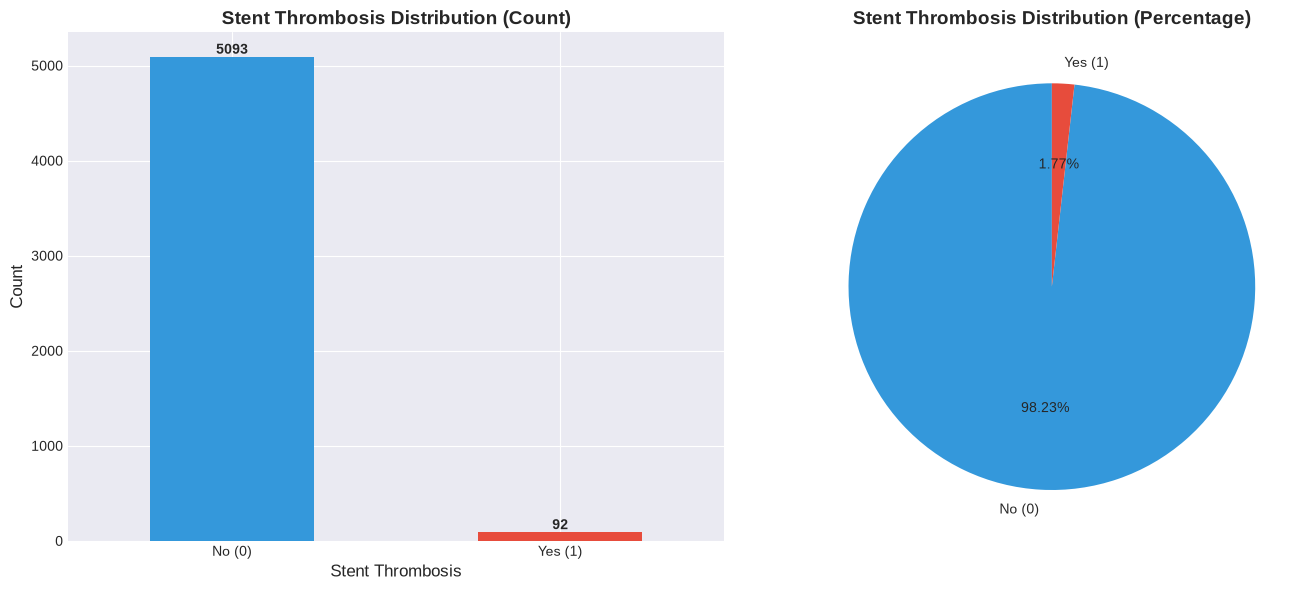

✓ Visualization saved: plots/01_target_distribution.png


In [12]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
target_counts.plot(kind="bar", ax=axes[0], color=["#3498db", "#e74c3c"])
axes[0].set_title(
    "Stent Thrombosis Distribution (Count)", fontsize=14, fontweight="bold"
)
axes[0].set_xlabel("Stent Thrombosis", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom", fontweight="bold")

# Pie chart
target_percent.plot(
    kind="pie",
    ax=axes[1],
    autopct="%1.2f%%",
    startangle=90,
    colors=["#3498db", "#e74c3c"],
    labels=["No (0)", "Yes (1)"],
)
axes[1].set_title(
    "Stent Thrombosis Distribution (Percentage)", fontsize=14, fontweight="bold"
)
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(
    str(PLOT_DIR / "01_target_distribution.png"), dpi=300, bbox_inches="tight"
)
plt.show()
print("✓ Visualization saved: plots/01_target_distribution.png")

## 6. Feature Categorization

Before diving into detailed analysis, we need to categorize features into different types:

- **Binary Features**: Variables that take only 0/1 values (e.g., presence/absence indicators)
- **Continuous Features**: Numeric variables that can take any value in a range (e.g., age, lab values)
- **Categorical Features**: Text or nominal variables (e.g., stent type names)

This categorization helps us choose appropriate statistical tests and visualization methods for each feature type.


In [13]:
# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Remove target from numeric for analysis
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

# Binary columns (0/1)
binary_cols = []
for col in numeric_cols:
    unique_vals = df[col].dropna().unique()
    if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1, np.nan}):
        binary_cols.append(col)

# Continuous numeric columns
continuous_cols = [col for col in numeric_cols if col not in binary_cols]

print("=" * 80)
print("FEATURE CATEGORIZATION")
print("=" * 80)

print("\nFeature categories:")
print(f"  Total features: {len(df.columns) - 1} (excluding target)")
print(f"  Binary features: {len(binary_cols)}")
print(f"  Continuous features: {len(continuous_cols)}")
print(f"  Categorical features: {len(categorical_cols)}")

print("\n\nSample binary features (first 10):")
for i, col in enumerate(binary_cols[:10], 1):
    print(f"  {i:2d}. {col}")

print("\n\nSample continuous features (first 10):")
for i, col in enumerate(continuous_cols[:10], 1):
    print(f"  {i:2d}. {col}")

if categorical_cols:
    print("\n\nCategorical features:")
    for i, col in enumerate(categorical_cols, 1):
        print(f"  {i:2d}. {col}")

FEATURE CATEGORIZATION

Feature categories:
  Total features: 82 (excluding target)
  Binary features: 57
  Continuous features: 24
  Categorical features: 1


Sample binary features (first 10):
   1. Men
   2. Diabetes
   3. Hypertension
   4. HL
   5. Current smoker
   6. Current drinking
   7. Stroke/TIA
   8. History of peripheral vascualr disease
   9. Chronic renal insufficiency
  10. History of HF


Sample continuous features (first 10):
   1. Age
   2. Time since stent implantation
   3. NO.of vessels
   4. Min-stent diameter
   5. Max-stent diameter
   6. Total stent length
   7. Stent release pressure
   8. No.of stents per lesion
   9. LV
  10. LVEF


Categorical features:
   1. Stent type-SES


## 7. Univariate Analysis - Continuous Variables

Univariate analysis examines individual features in isolation. For continuous variables, we'll look at:

- **Central Tendency**: Mean, median, mode
- **Dispersion**: Standard deviation, range, quartiles
- **Distribution Shape**: Skewness, kurtosis
- **Outliers**: Values that deviate significantly from the norm

Understanding these characteristics helps identify:
- Features that need transformation (e.g., log transformation for skewed data)
- Potential data quality issues
- Features with unusual distributions


In [14]:
# Summary statistics for continuous variables
if len(continuous_cols) > 0:
    print("=" * 80)
    print("UNIVARIATE ANALYSIS - CONTINUOUS VARIABLES")
    print("=" * 80)

    continuous_stats = df[continuous_cols].describe()
    print("\nSummary statistics for continuous variables:")
    display(continuous_stats.T.round(2))
else:
    print("No continuous variables found.")

UNIVARIATE ANALYSIS - CONTINUOUS VARIABLES

Summary statistics for continuous variables:


,count,mean,std,min,25%,50%,75%,max
Age,5185.0,59.85,9.95,28.00,53.00,60.00,67.00,89.00
Time since stent implantation,5185.0,1409.96,140.30,380.00,1319.00,1416.00,1514.00,1605.00
NO.of vessels,5185.0,1.87,0.82,1.00,1.00,2.00,3.00,4.00
Min-stent diameter,5185.0,2.99,0.41,2.25,2.75,3.00,3.00,5.00
Max-stent diameter,5185.0,3.06,0.41,2.25,2.75,3.00,3.50,5.00
Total stent length,5185.0,31.82,15.75,8.00,21.00,28.00,36.00,144.00
Stent release pressure,5185.0,13.95,2.98,6.00,12.00,14.00,16.00,24.00
No.of stents per lesion,5185.0,1.22,0.46,1.00,1.00,1.00,1.00,4.00
LV,5185.0,44.63,4.09,37.00,42.00,44.00,46.00,73.00
LVEF,5185.0,55.14,4.50,22.00,53.00,55.00,58.00,68.00


In [15]:
# Outlier detection using IQR method
if len(continuous_cols) > 0:
    print("\n" + "-" * 80)
    print("OUTLIER DETECTION (IQR Method)")
    print("-" * 80)

    outlier_summary = []
    for col in continuous_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        if IQR > 0:  # Avoid division by zero
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
            outlier_count = len(outliers)
            if outlier_count > 0:
                outlier_summary.append(
                    {
                        "Column": col,
                        "Outliers": outlier_count,
                        "Percentage": (outlier_count / len(df)) * 100,
                        "Lower Bound": lower_bound,
                        "Upper Bound": upper_bound,
                    }
                )

    if outlier_summary:
        outlier_df = pd.DataFrame(outlier_summary).sort_values(
            "Outliers", ascending=False
        )
        print("\nColumns with outliers (top 20):")
        display(outlier_df.head(20))
    else:
        print("✓ No outliers detected using IQR method")


--------------------------------------------------------------------------------
OUTLIER DETECTION (IQR Method)
--------------------------------------------------------------------------------

Columns with outliers (top 20):


,Column,Outliers,Percentage,Lower Bound,Upper Bound
2,Min-stent diameter,1348,25.998071,2.375,3.375
8,CaI,645,12.439730,-56.200,100.440
4,Total stent length,434,8.370299,-1.500,58.500
18,Fast-Glu,418,8.061716,1.620,10.820
6,LV,247,4.763742,36.000,52.000
7,LVEF,231,4.455159,45.500,65.500
12,Cre,194,3.741562,26.000,114.000
20,Fiberinogen,193,3.722276,1.240,4.920
19,HbA1c,159,3.066538,1.450,9.850
9,WBC,153,2.950820,0.135,16.415


## 8. Univariate Analysis - Binary Variables

For binary variables, we examine:
- **Prevalence**: What percentage of cases have the feature present (value = 1)?
- **Distribution**: Are the classes balanced or is one value much more common?

This helps identify:
- Rare features (very low or very high prevalence) that may have limited predictive power
- Features with balanced distributions that might be more informative


In [16]:
# Binary variable analysis
if len(binary_cols) > 0:
    print("=" * 80)
    print("UNIVARIATE ANALYSIS - BINARY VARIABLES")
    print("=" * 80)

    binary_summary = []
    for col in binary_cols:
        positive_count = df[col].sum()
        positive_pct = (positive_count / len(df)) * 100
        binary_summary.append(
            {
                "Column": col,
                "Positive (1)": positive_count,
                "Negative (0)": len(df) - positive_count,
                "Percentage Positive": positive_pct,
            }
        )

    binary_df = pd.DataFrame(binary_summary).sort_values("Percentage Positive")
    print("\nBinary variable distribution (sorted by prevalence):")
    display(binary_df.head(20))

    print("\n...")
    print(f"\nTotal binary variables analyzed: {len(binary_df)}")

UNIVARIATE ANALYSIS - BINARY VARIABLES

Binary variable distribution (sorted by prevalence):


,Column,Positive (1),Negative (0),Percentage Positive
29,Aneurysm,28.0,5157.0,0.540019
31,Ulceration,39.0,5146.0,0.752170
43,No reflow,44.0,5141.0,0.848602
44,Dissection,53.0,5132.0,1.022179
30,Vessel dialation,59.0,5126.0,1.137898
24,Moderate/severe tortuosity,60.0,5125.0,1.157184
8,Chronic renal insufficiency,64.0,5121.0,1.234330
7,History of peripheral vascualr disease,88.0,5097.0,1.697203
55,Ticagrelor,91.0,5094.0,1.755063
11,Previous PCI,104.0,5081.0,2.005786



...

Total binary variables analyzed: 57


## 9. Bivariate Analysis - Correlations

Bivariate analysis examines relationships between features and the target variable. Correlation analysis helps us:

- **Identify Important Features**: Features with strong correlations are likely to be predictive
- **Understand Direction**: Positive correlation means feature increases with target, negative means it decreases
- **Detect Multicollinearity**: High correlations between features can indicate redundancy

We'll calculate Pearson correlation coefficients for numeric features with the target variable.


In [17]:
# Calculate correlations with target
if TARGET_COL in df.columns:
    correlations = (
        df[numeric_cols + [TARGET_COL]].corr()[TARGET_COL].sort_values(ascending=False)
    )
    correlations = correlations[correlations.index != TARGET_COL]

    print("=" * 80)
    print("BIVARIATE ANALYSIS - CORRELATIONS")
    print("=" * 80)

    print("\nTop 20 features most correlated with Stent thrombosis:")
    print(correlations.head(20).to_string())

    print("\n\nBottom 20 features least correlated with Stent thrombosis:")
    print(correlations.tail(20).to_string())

    # Strong correlations (absolute value > 0.3)
    strong_corr = correlations[abs(correlations) > 0.3]
    if len(strong_corr) > 0:
        print(f"\n✓ Found {len(strong_corr)} features with |correlation| > 0.3:")
        print(strong_corr.to_string())
    else:
        print("\n⚠ No features found with |correlation| > 0.3")

BIVARIATE ANALYSIS - CORRELATIONS

Top 20 features most correlated with Stent thrombosis:
WBC                        0.150203
LV                         0.147245
No postdilation            0.089266
Previous PCI               0.084973
CKD90                      0.062602
No.of stents per lesion    0.060360
Total stent length         0.056651
Fast-Glu                   0.053844
3-vessel disease           0.052003
NO.of vessels              0.051149
CKD5                       0.048615
Diabetes                   0.041555
PES                        0.039530
HbA1c                      0.038787
Multi-vessel CAD           0.038040
stent overlap              0.034669
TIMI-0                     0.033180
LDL                        0.029883
Stroke/TIA                 0.029607
Fiberinogen                0.029211


Bottom 20 features least correlated with Stent thrombosis:
Visual thrombus                 -0.002793
HL                              -0.003454
History of HF                   -0.003924
P-L

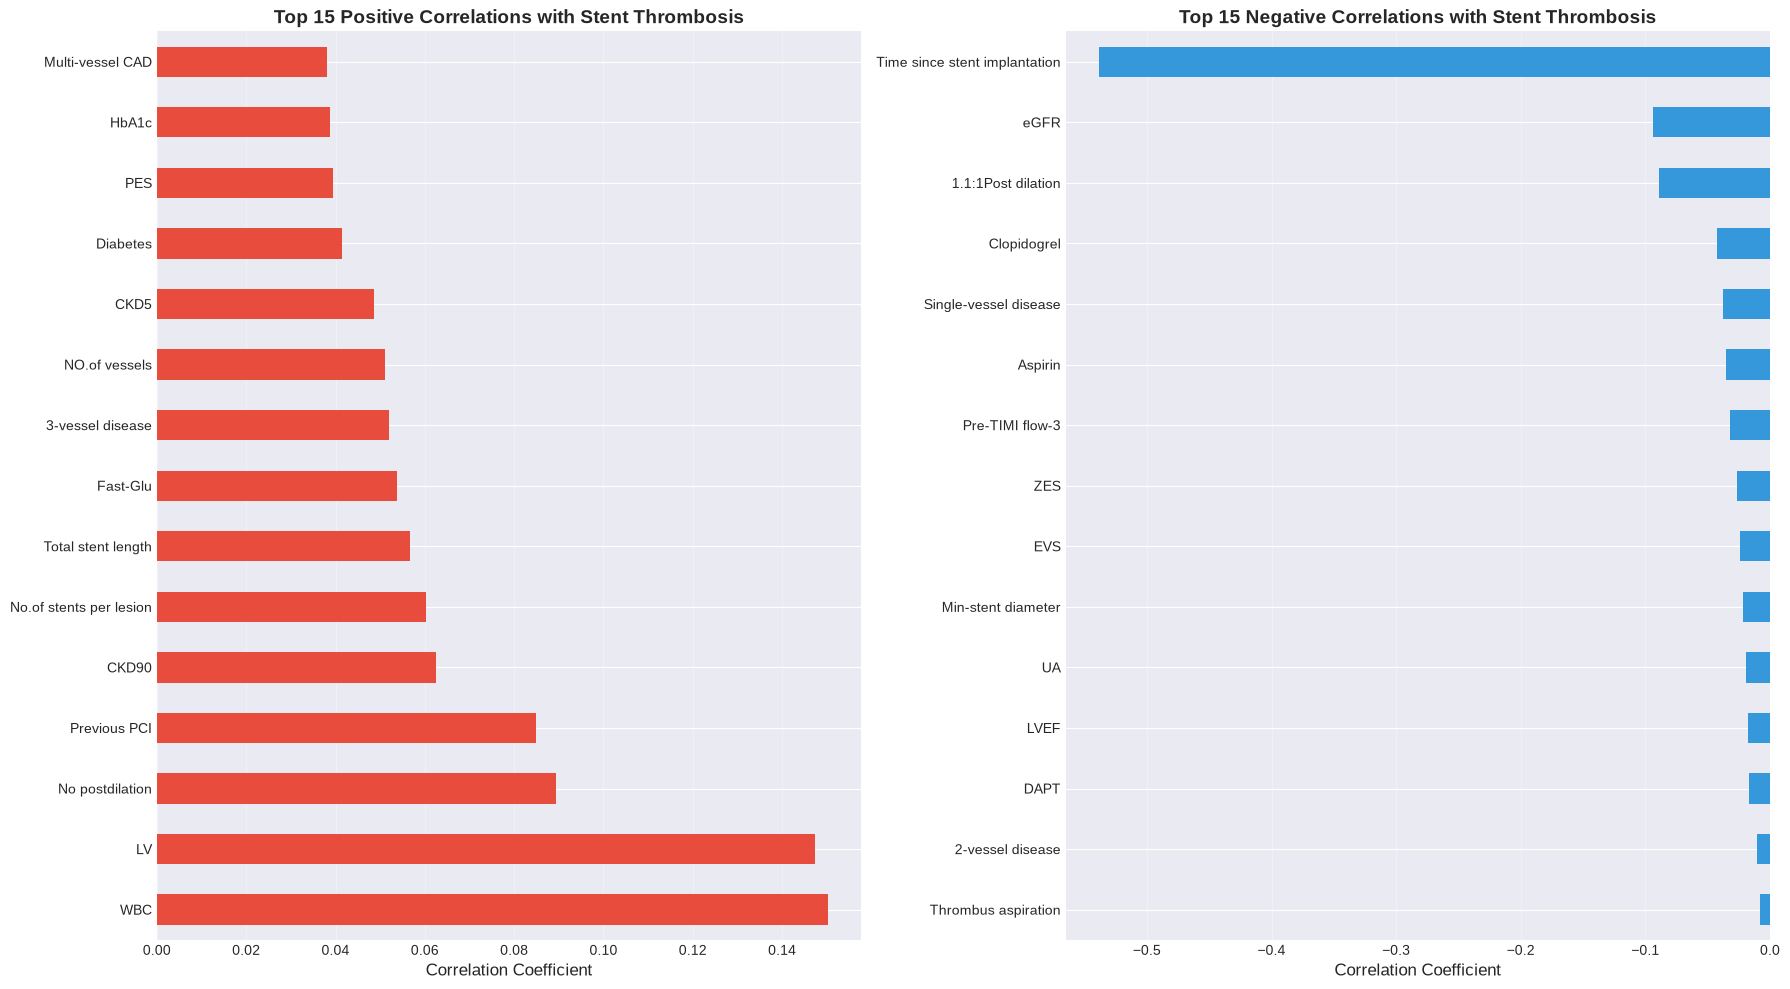

✓ Visualization saved: plots/07_top_correlations.png


In [18]:
# Visualize top correlations
if TARGET_COL in df.columns and len(correlations) > 0:
    top_pos = correlations.head(15)
    top_neg = correlations.tail(15)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))

    # Positive correlations
    top_pos.plot(kind="barh", ax=axes[0], color="#e74c3c")
    axes[0].set_title(
        "Top 15 Positive Correlations with Stent Thrombosis",
        fontsize=14,
        fontweight="bold",
    )
    axes[0].set_xlabel("Correlation Coefficient", fontsize=12)
    axes[0].grid(True, alpha=0.3, axis="x")

    # Negative correlations
    top_neg.plot(kind="barh", ax=axes[1], color="#3498db")
    axes[1].set_title(
        "Top 15 Negative Correlations with Stent Thrombosis",
        fontsize=14,
        fontweight="bold",
    )
    axes[1].set_xlabel("Correlation Coefficient", fontsize=12)
    axes[1].grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig(
        str(PLOT_DIR / "07_top_correlations.png"), dpi=300, bbox_inches="tight"
    )
    plt.show()
    print("✓ Visualization saved: plots/07_top_correlations.png")

In [ ]:
# Clean Pearson correlation heatmaps (top 42 / next 41 blocks)
TOP_N = 42
NEXT_N = 41

if len(continuous_cols) > 0:
    top_corr_features = correlations.abs().nlargest(TOP_N).index.tolist()
    next_corr_features = (
        correlations.abs().drop(top_corr_features, errors="ignore").nlargest(NEXT_N).index.tolist()
    )
    next_corr_features = [f for f in next_corr_features if f not in set(top_corr_features)]


    def _heatmap_figsize(n_rows, n_cols):
        # ~0.48 inches per label keeps ~40x40 matrices readable at 300 dpi
        return (max(18, n_cols * 0.48), max(18, n_rows * 0.48))


    def plot_corr_heatmap(corr_data, title, out_path, figsize=None):
        if figsize is None:
            figsize = _heatmap_figsize(*corr_data.shape)
        fig, ax = plt.subplots(figsize=figsize)
        sns.heatmap(
            corr_data,
            annot=False,
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0,
            cbar_kws={"shrink": 0.85, "label": "Pearson r"},
            xticklabels=True,
            yticklabels=True,
        )
        ax.set_title(title, fontsize=15, fontweight="bold", pad=12)
        ax.tick_params(axis="x", labelrotation=55, labelsize=8)
        ax.tick_params(axis="y", labelrotation=0, labelsize=8)
        plt.tight_layout()
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"✓ Visualization saved: {out_path.split('/')[-1]} ({corr_data.shape[0]}×{corr_data.shape[1]})")


    def features_with_target(feature_list):
        """Append target once (avoid duplicate Stent thrombosis labels)."""
        return list(dict.fromkeys(list(feature_list) + [TARGET_COL]))


    def block_corr_matrix(row_features, col_features, method=None):
        """Build cross-block correlation without duplicate target columns."""
        row_labels = features_with_target(row_features)
        col_labels = features_with_target(col_features)
        all_unique = list(dict.fromkeys(row_labels + col_labels))
        corr_kwargs = {"method": method} if method else {}
        full_corr = df[all_unique].corr(**corr_kwargs)
        return full_corr.loc[row_labels, col_labels]


    top_with_target = features_with_target(top_corr_features)
    next_with_target = features_with_target(next_corr_features)

    # 1) Top 42 features + target (43×43)
    corr_top42_target = block_corr_matrix(top_corr_features, top_corr_features)
    plot_corr_heatmap(
        corr_top42_target,
        f"Pearson Correlation Heatmap: Top {TOP_N} Features + Target",
        str(PLOT_DIR / "03_correlation_heatmap_top42_target.png"),
    )

    # 2) Next 41 features + target (42×42)
    if len(next_corr_features) > 0:
        corr_next41_target = block_corr_matrix(next_corr_features, next_corr_features)
        plot_corr_heatmap(
            corr_next41_target,
            f"Pearson Correlation Heatmap: Next {NEXT_N} Features + Target",
            str(PLOT_DIR / "03_correlation_heatmap_next41_target.png"),
        )

        # 3) Cross block: top 42 + target vs next 41 + target
        top_next_cross = block_corr_matrix(top_corr_features, next_corr_features)
        plot_corr_heatmap(
            top_next_cross,
            f"Pearson Cross-Correlation: Top {TOP_N}+Target vs Next {NEXT_N}+Target",
            str(PLOT_DIR / "03_correlation_heatmap_top42_vs_next41_with_target.png"),
        )


## 9b. Spearman Correlation Check (Robustness)

Pearson captures **linear** relationships, while Spearman captures **monotonic rank-based** relationships and is more robust to outliers and non-normality.

In this section, we compute Spearman correlations with the target and compare them to Pearson results from Section 9 to decide which metric is more appropriate for this dataset.

In [ ]:
# Spearman correlations with target (robust alternative to Pearson)
SPEARMAN_DATA_PATH = REPO_ROOT / "data" / "raw" / "VLST.csv"

# Use existing dataframe if available; otherwise load from provided path
if "df" not in locals() or df is None or len(df) == 0:
    df = pd.read_csv(SPEARMAN_DATA_PATH)
    print(f"Loaded data from: {SPEARMAN_DATA_PATH}")
# Ensure numeric columns list exists
if "numeric_cols" not in locals() or numeric_cols is None or len(numeric_cols) == 0:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if TARGET_COL in df.columns:
    # Spearman with target
    spearman_correlations = (
        df[numeric_cols + [TARGET_COL]]
        .corr(method="spearman")[TARGET_COL]
        .sort_values(ascending=False)
    )
    spearman_correlations = spearman_correlations[spearman_correlations.index != TARGET_COL]

    # Pearson from previous section (fallback compute if needed)
    if "correlations" not in locals() or correlations is None or len(correlations) == 0:
        correlations = (
            df[numeric_cols + [TARGET_COL]].corr()[TARGET_COL].sort_values(ascending=False)
        )
        correlations = correlations[correlations.index != TARGET_COL]

    # Align and compare
    common_features = correlations.index.intersection(spearman_correlations.index)
    comparison_df = pd.DataFrame(
        {
            "Feature": common_features,
            "Pearson": correlations.loc[common_features].values,
            "Spearman": spearman_correlations.loc[common_features].values,
        }
    )
    comparison_df["Abs_Diff"] = (
            comparison_df["Pearson"].abs() - comparison_df["Spearman"].abs()
    ).abs()

    # Save comparison
    comparison_df.sort_values("Abs_Diff", ascending=False).to_csv(
        str(PLOT_DIR / "pearson_vs_spearman_comparison.csv"), index=False
    )

    print("=" * 80)
    print("PEARSON vs SPEARMAN CORRELATION COMPARISON")
    print("=" * 80)
    print(f"Compared features: {len(comparison_df)}")
    print(
        f"Mean |difference| in absolute correlation: {comparison_df['Abs_Diff'].mean():.4f}"
    )

    # Top overlap by absolute importance
    top_k = 10
    top_pearson = set(correlations.abs().nlargest(top_k).index)
    top_spearman = set(spearman_correlations.abs().nlargest(top_k).index)
    overlap = len(top_pearson.intersection(top_spearman))

    print(
        f"Top-{top_k} overlap (by absolute correlation): {overlap}/{top_k} ({overlap / top_k:.0%})"
    )

    print("\nTop 10 Pearson (abs):")
    print(correlations.abs().nlargest(10).to_string())

    print("\nTop 10 Spearman (abs):")
    print(spearman_correlations.abs().nlargest(10).to_string())

    print("\nTop 20 features with largest Pearson-Spearman differences:")
    display(comparison_df.sort_values("Abs_Diff", ascending=False).head(20))

    print("\n✓ Saved: plots/pearson_vs_spearman_comparison.csv")
else:
    print(f"Target column '{TARGET_COL}' not found in dataframe.")

In [ ]:
# Recommendation: which correlation test to prioritize for this dataset
if "comparison_df" in locals() and len(comparison_df) > 0:
    agreement_ratio = (comparison_df["Abs_Diff"] < 0.05).mean()

    # Compare strength counts
    pearson_strong = (comparison_df["Pearson"].abs() >= 0.1).sum()
    spearman_strong = (comparison_df["Spearman"].abs() >= 0.1).sum()

    print("\n" + "=" * 80)
    print("RECOMMENDATION: PEARSON OR SPEARMAN?")
    print("=" * 80)
    print(f"Agreement ratio (|abs(Pearson)-abs(Spearman)| < 0.05): {agreement_ratio:.1%}")
    print(f"Features with |corr| >= 0.10 -> Pearson: {pearson_strong}, Spearman: {spearman_strong}")

    if agreement_ratio >= 0.80:
        print("\nRecommendation:")
        print(
            "✓ Pearson and Spearman are highly consistent on this dataset. "
            "Use Pearson for primary reporting (easier interpretation of linear effect size), "
            "and keep Spearman as a robustness/sensitivity check."
        )
    elif spearman_strong > pearson_strong:
        print("\nRecommendation:")
        print(
            "⚠ Spearman appears more informative than Pearson for several features. "
            "Prioritize Spearman in EDA summaries because relationships are likely monotonic/non-linear "
            "or influenced by outliers."
        )
    else:
        print("\nRecommendation:")
        print(
            "⚠ Pearson and Spearman differ meaningfully. Report both, "
            "but prioritize interpretation based on model family: Pearson for linear assumptions, "
            "Spearman for robust rank-based screening."
        )
else:
    print("Run the Spearman comparison cell first to generate recommendation metrics.")

In [ ]:
# Spearman visualizations (same presentation style as Pearson)
if TARGET_COL in df.columns and "spearman_correlations" in locals() and len(spearman_correlations) > 0:
    # Top positive / negative Spearman correlations
    top_pos_s = spearman_correlations.head(15)
    top_neg_s = spearman_correlations.tail(15)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))

    top_pos_s.plot(kind="barh", ax=axes[0], color="#e74c3c")
    axes[0].set_title(
        "Top 15 Positive Spearman Correlations with Stent Thrombosis",
        fontsize=14,
        fontweight="bold",
    )
    axes[0].set_xlabel("Spearman Correlation Coefficient", fontsize=12)
    axes[0].grid(True, alpha=0.3, axis="x")

    top_neg_s.plot(kind="barh", ax=axes[1], color="#3498db")
    axes[1].set_title(
        "Top 15 Negative Spearman Correlations with Stent Thrombosis",
        fontsize=14,
        fontweight="bold",
    )
    axes[1].set_xlabel("Spearman Correlation Coefficient", fontsize=12)
    axes[1].grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig(
        str(PLOT_DIR / "07b_top_spearman_correlations.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("✓ Visualization saved: plots/07b_top_spearman_correlations.png")

    # Spearman heatmaps by ranked feature blocks (top 42 / next 41)
    TOP_N = 42
    NEXT_N = 41

    top_spearman_features = spearman_correlations.abs().nlargest(TOP_N).index.tolist()
    next_spearman_features = (
        spearman_correlations.abs().drop(top_spearman_features, errors="ignore").nlargest(NEXT_N).index.tolist()
    )
    next_spearman_features = [f for f in next_spearman_features if f not in set(top_spearman_features)]


    def _spearman_heatmap_figsize(n_rows, n_cols):
        return (max(18, n_cols * 0.48), max(18, n_rows * 0.48))


    def plot_spearman_heatmap(corr_data, title, out_path, figsize=None):
        if figsize is None:
            figsize = _spearman_heatmap_figsize(*corr_data.shape)
        fig, ax = plt.subplots(figsize=figsize)
        sns.heatmap(
            corr_data,
            annot=False,
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0,
            cbar_kws={"shrink": 0.85, "label": "Spearman rho"},
            xticklabels=True,
            yticklabels=True,
        )
        ax.set_title(title, fontsize=15, fontweight="bold", pad=12)
        ax.tick_params(axis="x", labelrotation=55, labelsize=8)
        ax.tick_params(axis="y", labelrotation=0, labelsize=8)
        plt.tight_layout()
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"✓ Visualization saved: {out_path.split('/')[-1]} ({corr_data.shape[0]}×{corr_data.shape[1]})")


    def features_with_target(feature_list):
        """Append target once (avoid duplicate Stent thrombosis labels)."""
        return list(dict.fromkeys(list(feature_list) + [TARGET_COL]))


    def block_spearman_corr_matrix(row_features, col_features, method=None):
        """Build cross-block correlation without duplicate target columns."""
        row_labels = features_with_target(row_features)
        col_labels = features_with_target(col_features)
        all_unique = list(dict.fromkeys(row_labels + col_labels))
        corr_kwargs = {"method": method} if method else {}
        full_corr = df[all_unique].corr(**corr_kwargs)
        return full_corr.loc[row_labels, col_labels]


    # 1) Top 42 features + target (43×43)
    spearman_top42_target = block_spearman_corr_matrix(top_spearman_features, top_spearman_features, method="spearman")
    plot_spearman_heatmap(
        spearman_top42_target,
        f"Spearman Correlation Heatmap: Top {TOP_N} Features + Target",
        str(PLOT_DIR / "03b_spearman_correlation_heatmap_top42_target.png"),
    )

    # 2) Next 41 features + target (42×42)
    if len(next_spearman_features) > 0:
        spearman_next41_target = block_spearman_corr_matrix(
            next_spearman_features, next_spearman_features, method="spearman"
        )
        plot_spearman_heatmap(
            spearman_next41_target,
            f"Spearman Correlation Heatmap: Next {NEXT_N} Features + Target",
            str(PLOT_DIR / "03b_spearman_correlation_heatmap_next41_target.png"),
        )

        # 3) Cross block: top 42 + target vs next 41 + target
        top_next_spearman_cross = block_spearman_corr_matrix(
            top_spearman_features, next_spearman_features, method="spearman"
        )
        plot_spearman_heatmap(
            top_next_spearman_cross,
            f"Spearman Cross-Correlation: Top {TOP_N}+Target vs Next {NEXT_N}+Target",
            str(PLOT_DIR / "03b_spearman_correlation_heatmap_top42_vs_next41_with_target.png"),
        )

    # Save Spearman ranking table for parity with Pearson outputs
    spearman_df = pd.DataFrame(
        {
            "Feature": spearman_correlations.index,
            "Spearman_Correlation": spearman_correlations.values,
            "Abs_Spearman_Correlation": spearman_correlations.abs().values,
        }
    ).sort_values("Abs_Spearman_Correlation", ascending=False)
    spearman_df.to_csv(
        str(PLOT_DIR / "spearman_correlations_with_target.csv"), index=False
    )
    print("✓ Saved: plots/spearman_correlations_with_target.csv")
else:
    print("Run the Spearman correlation calculation cell first.")

## 10. Statistical Tests - Association with Target

While correlation quantifies association strength (Pearson for linear, Spearman for rank/monotonic), statistical tests determine whether observed group differences are likely due to chance.

### Tests Used:

1. **Continuous variables** — compare values between VLST groups (no stent thrombosis vs stent thrombosis):
   - **One-way ANOVA** (`scipy.stats.f_oneway`): used when the feature is not highly skewed (|skewness| ≤ 1). With a binary target this is equivalent to a two-sample t-test, but ANOVA generalizes to more than two groups.
   - **Kruskal-Wallis H test** (`scipy.stats.kruskal`): non-parametric alternative used when |skewness| > 1, consistent with the distribution shape analysis in section 16.5.

   Test choice is based on skewness computed on all non-missing values for each continuous feature.

2. **Binary variables** — full suite of 2×2 association tests vs VLST (run on **all** binary features):
   - **Chi-square** (Pearson) and **Chi-square with Yates continuity correction**
   - **Fisher's exact test** (exact p-value; preferred when any expected cell count < 5)
   - **Barnard's exact test** (unconditional exact alternative to Fisher)
   - **Boschloo's exact test** (only when expected counts are sparse / min expected < 5; slower)
   - Effect sizes: **Odds ratio (OR)**, **Relative risk (RR)**, **Risk difference**, **Phi coefficient**

   Primary recommended p-value: Fisher if min expected < 5, otherwise Chi-square.

**Important Note**: Switching correlation method (Pearson vs Spearman) does **not** require changing these group-comparison tests.

**Significance Level**: p < 0.05 indicates statistical significance


In [23]:
# Separate data by target
target_0 = df[df[TARGET_COL] == 0]
target_1 = df[df[TARGET_COL] == 1]

SKEW_THRESHOLD = 1.0  # |skewness| > 1 => highly skewed => Kruskal-Wallis

print("=" * 80)
print("STATISTICAL TESTS - ASSOCIATION WITH TARGET")
print("=" * 80)
print(f"\nGroup sizes: Class 0 = {len(target_0):,}, Class 1 = {len(target_1):,}")

print("\n" + "-" * 80)
print("Continuous Variables: One-way ANOVA or Kruskal-Wallis (by skewness)")
print("-" * 80)
print(
    f"Rule: |skewness| > {SKEW_THRESHOLD} -> Kruskal-Wallis; otherwise -> one-way ANOVA"
)

continuous_test_results = []
for col in continuous_cols:
    try:
        group_0 = target_0[col].dropna()
        group_1 = target_1[col].dropna()

        if len(group_0) <= 3 or len(group_1) <= 3:
            continue

        pooled = df[col].dropna()
        if len(pooled) <= 3:
            continue

        feature_skew = skew(pooled)
        use_kruskal = abs(feature_skew) > SKEW_THRESHOLD

        if use_kruskal:
            stat, p_value = kruskal(group_0, group_1)
            test_name = "Kruskal-Wallis"
        else:
            stat, p_value = f_oneway(group_0, group_1)
            test_name = "One-way ANOVA"

        pearson_r = df[[col, TARGET_COL]].corr().iloc[0, 1]
        spearman_rho = df[[col, TARGET_COL]].corr(method="spearman").iloc[0, 1]

        continuous_test_results.append(
            {
                "Feature": col,
                "Skewness": feature_skew,
                "Test": test_name,
                "Statistic": stat,
                "P-value": p_value,
                "Pearson r": pearson_r,
                "Spearman rho": spearman_rho,
                "Direction (Pearson)": "Positive" if pearson_r > 0 else "Negative",
                "Direction (Spearman)": "Positive" if spearman_rho > 0 else "Negative",
                "Mean (no VLST)": group_0.mean(),
                "Mean (VLST)": group_1.mean(),
                "Median (no VLST)": group_0.median(),
                "Median (VLST)": group_1.median(),
                "Significant": "Yes" if p_value < 0.05 else "No",
            }
        )
    except Exception:
        pass

if continuous_test_results:
    continuous_test_df = pd.DataFrame(continuous_test_results).sort_values("P-value")

    n_anova = (continuous_test_df["Test"] == "One-way ANOVA").sum()
    n_kruskal = (continuous_test_df["Test"] == "Kruskal-Wallis").sum()
    print(f"\nTests run: {len(continuous_test_df)} continuous features")
    print(f"  One-way ANOVA: {n_anova}")
    print(f"  Kruskal-Wallis: {n_kruskal}")

    print("\nTop 20 features by statistical significance:")
    display(
        continuous_test_df[
            [
                "Feature",
                "Skewness",
                "Test",
                "Statistic",
                "P-value",
                "Mean (no VLST)",
                "Mean (VLST)",
                "Significant",
            ]
        ].head(20)
    )

    significant_continuous = continuous_test_df[continuous_test_df["P-value"] < 0.05]
    print(
        f"\n✓ Found {len(significant_continuous)} continuous features with significant association (p < 0.05)"
    )

    continuous_test_df.to_csv(
        str(PLOT_DIR / "continuous_target_association_tests.csv"),
        index=False,
    )
    print("✓ Saved: plots/continuous_target_association_tests.csv")
else:
    print("No valid continuous-variable test results obtained.")

STATISTICAL TESTS - ASSOCIATION WITH TARGET

Group sizes: Class 0 = 5,093, Class 1 = 92

--------------------------------------------------------------------------------
Continuous Variables: One-way ANOVA or Kruskal-Wallis (by skewness)
--------------------------------------------------------------------------------
Rule: |skewness| > 1.0 -> Kruskal-Wallis; otherwise -> one-way ANOVA

Tests run: 24 continuous features
  One-way ANOVA: 10
  Kruskal-Wallis: 14

Top 20 features by statistical significance:


,Feature,Skewness,Test,Statistic,P-value,Mean (no VLST),Mean (VLST),Significant
1,Time since stent implantation,-2.359276,Kruskal-Wallis,150.042239,1.697177e-34,1420.109169,848.054348,Yes
8,LV,0.965313,One-way ANOVA,114.862664,1.596386e-26,44.548203,49.108696,Yes
11,WBC,1.211996,Kruskal-Wallis,87.628082,7.899510e-21,8.746701,12.491739,Yes
15,eGFR,0.063042,One-way ANOVA,45.865905,1.406839e-11,120.028908,95.875978,Yes
16,CKD5,2.617650,Kruskal-Wallis,19.185443,1.186145e-05,1.206754,1.391304,Yes
7,No.of stents per lesion,2.131825,Kruskal-Wallis,14.486191,1.411908e-04,1.213234,1.423913,Yes
22,HbA1c,1.396370,Kruskal-Wallis,13.854982,1.974725e-04,5.800079,6.274239,Yes
2,NO.of vessels,0.243686,One-way ANOVA,13.595589,2.290374e-04,1.865894,2.184783,Yes
5,Total stent length,1.737190,Kruskal-Wallis,10.614366,1.122124e-03,31.697821,38.456522,Yes
23,Fiberinogen,1.621689,Kruskal-Wallis,6.324249,1.190979e-02,3.170416,3.365652,Yes



✓ Found 12 continuous features with significant association (p < 0.05)
✓ Saved: plots/continuous_target_association_tests.csv


VLST CORRELATION DIRECTION — SIGNIFICANT CONTINUOUS FEATURES
Positive: higher feature values associate with higher VLST risk
Negative: higher feature values associate with lower VLST risk


,Feature,Test,P-value,Pearson r,Direction (Pearson),Spearman rho,Direction (Spearman),Mean (no VLST),Mean (VLST),Median (no VLST),Median (VLST)
0,Time since stent implantation,Kruskal-Wallis,1.697177e-34,-0.538354,Negative,-0.170127,Negative,1420.109169,848.054348,1419.00,736.000
1,LV,One-way ANOVA,1.596386e-26,0.147245,Positive,0.139046,Positive,44.548203,49.108696,44.00,48.000
2,WBC,Kruskal-Wallis,7.899510e-21,0.150203,Positive,0.130014,Positive,8.746701,12.491739,8.00,11.820
3,eGFR,One-way ANOVA,1.406839e-11,-0.093657,Negative,-0.096342,Negative,120.028908,95.875978,114.46,96.885
4,CKD5,Kruskal-Wallis,1.186145e-05,0.048615,Positive,0.060835,Positive,1.206754,1.391304,1.00,1.000
5,No.of stents per lesion,Kruskal-Wallis,1.411908e-04,0.060360,Positive,0.052862,Positive,1.213234,1.423913,1.00,1.000
6,HbA1c,Kruskal-Wallis,1.974725e-04,0.038787,Positive,0.051698,Positive,5.800079,6.274239,5.40,6.450
7,NO.of vessels,One-way ANOVA,2.290374e-04,0.051149,Positive,0.050256,Positive,1.865894,2.184783,2.00,2.000
8,Total stent length,Kruskal-Wallis,1.122124e-03,0.056651,Positive,0.045250,Positive,31.697821,38.456522,28.00,30.000
9,Fiberinogen,Kruskal-Wallis,1.190979e-02,0.029211,Positive,0.034928,Positive,3.170416,3.365652,3.03,3.200



Significant continuous features: 12
  Positive Spearman association with VLST: 9
  Negative Spearman association with VLST: 3


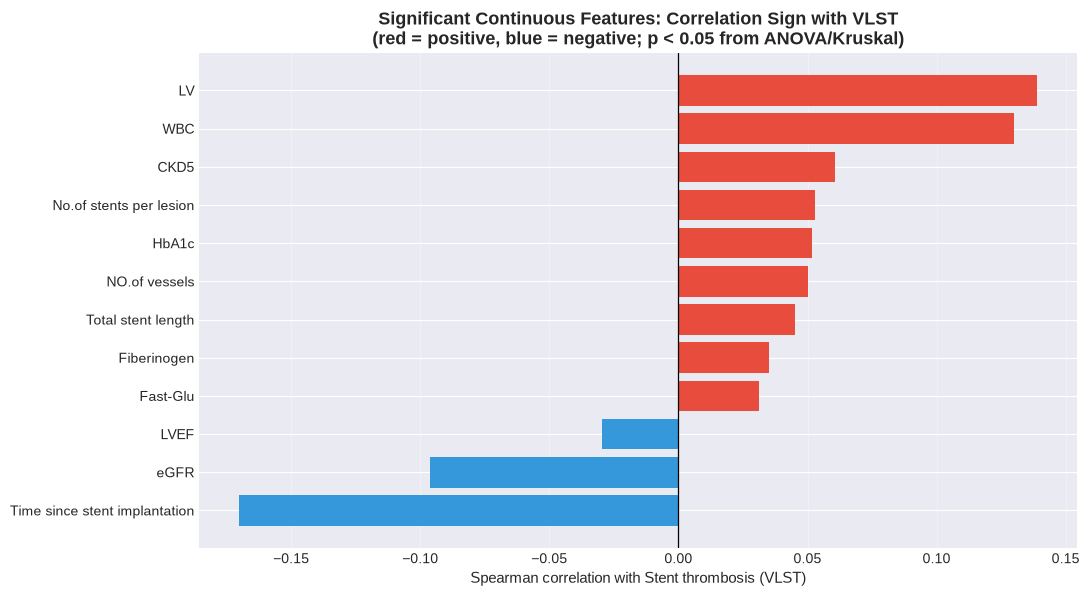

✓ Visualization saved: 10_significant_continuous_vlst_correlation_direction.png
✓ Saved: significant_continuous_vlst_correlation_direction.csv


In [24]:
# Correlation direction for continuous features with significant VLST association (p < 0.05)
# Depends on continuous_test_df / significant_continuous from the previous cell.

print("=" * 80)
print("VLST CORRELATION DIRECTION — SIGNIFICANT CONTINUOUS FEATURES")
print("=" * 80)
print(
    "Positive: higher feature values associate with higher VLST risk\n"
    "Negative: higher feature values associate with lower VLST risk"
)

if "continuous_test_df" not in globals() or continuous_test_df.empty:
    print("Run the continuous statistical-tests cell above first.")
else:
    sig_corr = (
        continuous_test_df[continuous_test_df["P-value"] < 0.05]
        .copy()
        .sort_values("Spearman rho", key=lambda s: s.abs(), ascending=False)
    )

    if sig_corr.empty:
        print("No continuous features with p < 0.05.")
    else:
        display_cols = [
            "Feature",
            "Test",
            "P-value",
            "Pearson r",
            "Direction (Pearson)",
            "Spearman rho",
            "Direction (Spearman)",
            "Mean (no VLST)",
            "Mean (VLST)",
            "Median (no VLST)",
            "Median (VLST)",
        ]
        display(sig_corr[display_cols].reset_index(drop=True))

        n_pos = (sig_corr["Spearman rho"] > 0).sum()
        n_neg = (sig_corr["Spearman rho"] < 0).sum()
        print(f"\nSignificant continuous features: {len(sig_corr)}")
        print(f"  Positive Spearman association with VLST: {n_pos}")
        print(f"  Negative Spearman association with VLST: {n_neg}")

        # Prefer Spearman for signed strength (robust to skew); bar color = direction
        plot_df = sig_corr.sort_values("Spearman rho")
        colors = ["#e74c3c" if v > 0 else "#3498db" for v in plot_df["Spearman rho"]]

        fig_h = max(6, 0.38 * len(plot_df) + 1.5)
        fig, ax = plt.subplots(figsize=(11, fig_h))
        ax.barh(plot_df["Feature"], plot_df["Spearman rho"], color=colors)
        ax.axvline(0, color="black", linewidth=0.9)
        ax.set_xlabel("Spearman correlation with Stent thrombosis (VLST)", fontsize=11)
        ax.set_title(
            "Significant Continuous Features: Correlation Sign with VLST\n"
            "(red = positive, blue = negative; p < 0.05 from ANOVA/Kruskal)",
            fontsize=13,
            fontweight="bold",
        )
        ax.grid(True, axis="x", alpha=0.3)
        plt.tight_layout()
        out_png = str(PLOT_DIR / "10_significant_continuous_vlst_correlation_direction.png")
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"✓ Visualization saved: {out_png.split('/')[-1]}")

        out_csv = str(PLOT_DIR / "significant_continuous_vlst_correlation_direction.csv")
        sig_corr[display_cols].to_csv(out_csv, index=False)
        print(f"✓ Saved: {out_csv.split('/')[-1]}")


In [ ]:
# Binary variables vs VLST: all applicable 2x2 tests + full p-values for ALL binary features
from scipy.stats import fisher_exact, barnard_exact, boschloo_exact

print("\n" + "=" * 80)
print("BINARY VARIABLES vs VLST — FULL STATISTICAL TEST SUITE")
print("=" * 80)
print(f"Testing all {len(binary_cols)} binary features (not limited to top-N).")
print(
    "Tests: Chi-square, Chi-square (Yates), Fisher exact, Barnard exact;\n"
    "       Boschloo exact only when min expected count < 5 (sparse tables).\n"
    "Effect sizes: Odds Ratio, Relative Risk, Risk Difference, Phi."
)

binary_test_results = []
skipped = []

for col in binary_cols:
    try:
        tmp = df[[col, TARGET_COL]].dropna()
        tmp = tmp[tmp[col].isin([0, 1]) & tmp[TARGET_COL].isin([0, 1])]
        contingency = pd.crosstab(tmp[col], tmp[TARGET_COL])

        # Ensure full 2x2 index/columns even if a level is missing
        contingency = contingency.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
        table = contingency.values.astype(float)

        if table.sum() == 0 or table.sum(axis=1).min() == 0 or table.sum(axis=0).min() == 0:
            skipped.append((col, "degenerate table (empty row/column)"))
            continue

        # Cell counts: rows=feature (0/1), cols=target (0/1)
        a = table[1, 1]  # feature on, VLST yes
        b = table[1, 0]  # feature on, VLST no
        c = table[0, 1]  # feature off, VLST yes
        d = table[0, 0]  # feature off, VLST no

        chi2, chi2_p, dof, expected = chi2_contingency(table, correction=False)
        chi2_yates, chi2_yates_p, _, _ = chi2_contingency(table, correction=True)
        odds_ratio, fisher_p = fisher_exact(table, alternative="two-sided")
        min_expected = float(expected.min())

        barnard_p = np.nan
        try:
            barnard_p = float(barnard_exact(table).pvalue)
        except Exception:
            pass

        boschloo_p = np.nan
        if min_expected < 5:
            try:
                boschloo_p = float(boschloo_exact(table).pvalue)
            except Exception:
                pass

        risk_on = a / (a + b) if (a + b) > 0 else np.nan
        risk_off = c / (c + d) if (c + d) > 0 else np.nan
        risk_diff = (
            risk_on - risk_off
            if np.isfinite(risk_on) and np.isfinite(risk_off)
            else np.nan
        )
        rel_risk = (
            risk_on / risk_off
            if np.isfinite(risk_on) and np.isfinite(risk_off) and risk_off > 0
            else np.nan
        )
        n = table.sum()
        phi = (
            (a * d - b * c)
            / np.sqrt((a + b) * (c + d) * (a + c) * (b + d))
            if n > 0
            else np.nan
        )

        recommended = "Fisher exact" if min_expected < 5 else "Chi-square"
        recommended_p = fisher_p if min_expected < 5 else chi2_p

        binary_test_results.append(
            {
                "Feature": col,
                "n": int(n),
                "VLST rate (feature=1)": risk_on,
                "VLST rate (feature=0)": risk_off,
                "Odds Ratio": odds_ratio,
                "Relative Risk": rel_risk,
                "Risk Difference": risk_diff,
                "Phi": phi,
                "Min Expected": min_expected,
                "Chi-square": chi2,
                "Chi-square p-value": chi2_p,
                "Chi-square Yates p-value": chi2_yates_p,
                "Fisher p-value": fisher_p,
                "Barnard p-value": barnard_p,
                "Boschloo p-value": boschloo_p,
                "Recommended test": recommended,
                "Recommended p-value": recommended_p,
                "Significant (recommended p<0.05)": "Yes" if recommended_p < 0.05 else "No",
            }
        )
    except Exception as e:
        skipped.append((col, str(e)))

if binary_test_results:
    binary_test_df = pd.DataFrame(binary_test_results).sort_values(
        "Recommended p-value", ascending=True
    )
    # Keep chi2_df alias for compatibility with any later references
    chi2_df = binary_test_df[
        ["Feature", "Chi-square", "Chi-square p-value", "Significant (recommended p<0.05)"]
    ].rename(
        columns={
            "Chi-square": "Chi2",
            "Chi-square p-value": "P-value",
            "Significant (recommended p<0.05)": "Significant",
        }
    )

    pval_cols = [
        "Feature",
        "Recommended test",
        "Recommended p-value",
        "Chi-square p-value",
        "Chi-square Yates p-value",
        "Fisher p-value",
        "Barnard p-value",
        "Boschloo p-value",
        "Odds Ratio",
        "Relative Risk",
        "Risk Difference",
        "Phi",
        "Min Expected",
        "VLST rate (feature=1)",
        "VLST rate (feature=0)",
        "Significant (recommended p<0.05)",
    ]

    pd.set_option("display.max_rows", None)
    pd.set_option("display.width", 200)
    print(
        f"\nAll {len(binary_test_df)} binary features — full p-values "
        f"(sorted by recommended p):"
    )
    display(binary_test_df[pval_cols].reset_index(drop=True))

    significant = binary_test_df[
        binary_test_df["Significant (recommended p<0.05)"] == "Yes"
        ]
    print(
        f"\n✓ {len(significant)} / {len(binary_test_df)} binary features significant "
        f"by recommended test (p < 0.05)"
    )
    if not significant.empty:
        print("\nSignificant features only:")
        display(
            significant[
                [
                    "Feature",
                    "Recommended test",
                    "Recommended p-value",
                    "Chi-square p-value",
                    "Fisher p-value",
                    "Barnard p-value",
                    "Odds Ratio",
                    "Phi",
                ]
            ].reset_index(drop=True)
        )

    out_csv = str(PLOT_DIR / "binary_target_association_tests_full.csv")
    binary_test_df.to_csv(out_csv, index=False)
    print(f"✓ Saved full results: {out_csv.split('/')[-1]}")
else:
    binary_test_df = pd.DataFrame()
    chi2_df = pd.DataFrame()
    print("No valid binary-variable test results obtained.")

if skipped:
    print(f"\nSkipped {len(skipped)} features:")
    for name, reason in skipped:
        print(f"  - {name}: {reason}")


In [ ]:
# Fisher's Exact Test: Stent thrombosis rate in Men vs Women
from scipy.stats import fisher_exact

print("\n" + "-" * 80)
print("FISHER'S EXACT TEST: MEN vs WOMEN")
print("-" * 80)

sex_col_candidates = ["Men", "men", "Male", "male", "Sex", "sex", "Gender", "gender"]
sex_col = next((c for c in sex_col_candidates if c in df.columns), None)

if sex_col is None:
    print("Could not find a sex/gender column. Expected one of:")
    print(sex_col_candidates)
else:
    # Keep only rows with valid binary values (0/1) for sex and target
    tmp = df[[sex_col, TARGET_COL]].dropna().copy()
    tmp = tmp[tmp[sex_col].isin([0, 1]) & tmp[TARGET_COL].isin([0, 1])]

    contingency = pd.crosstab(tmp[sex_col], tmp[TARGET_COL])

    print(f"Using sex column: {sex_col}")
    print("\nContingency table [rows: sex (0/1), cols: thrombosis (0/1)]")
    display(contingency)

    if contingency.shape == (2, 2):
        odds_ratio, p_value = fisher_exact(contingency, alternative="two-sided")

        # Event rates for interpretation
        rate_women = contingency.loc[0, 1] / contingency.loc[0].sum() if contingency.loc[0].sum() > 0 else np.nan
        rate_men = contingency.loc[1, 1] / contingency.loc[1].sum() if contingency.loc[1].sum() > 0 else np.nan

        print(f"\nWomen thrombosis rate (sex=0): {rate_women:.4%}")
        print(f"Men thrombosis rate (sex=1):   {rate_men:.4%}")
        print(f"Odds Ratio: {odds_ratio:.4f}")
        print(f"P-value (Fisher exact, two-sided): {p_value:.6g}")

        if p_value < 0.05:
            print("\n✓ Significant difference in thrombosis rate between men and women (p < 0.05).")
        else:
            print("\n⚠ No statistically significant difference in thrombosis rate between men and women (p >= 0.05).")
    else:
        print("\nFisher's exact test requires a 2x2 table. Please check coding of sex/target as binary 0/1.")

In [23]:
# Alcohol use significance test vs Stent thrombosis
# Rule: use Fisher's exact for sparse 2x2 tables (expected count < 5), else Chi-square.

print("\n" + "-" * 80)
print("ALCOHOL USE vs STENT THROMBOSIS: SIGNIFICANCE TEST")
print("-" * 80)

alcohol_candidates = [
    "Current drinking",
    "current drinking",
    "Alcohol use",
    "alcohol use",
    "Alcohol",
    "alcohol",
    "Drinking",
    "drinking",
]

alcohol_col = next((c for c in alcohol_candidates if c in df.columns), None)

if alcohol_col is None:
    print("Could not find alcohol-use column. Tried:")
    print(alcohol_candidates)
else:
    tmp = df[[alcohol_col, TARGET_COL]].dropna().copy()
    tmp = tmp[tmp[alcohol_col].isin([0, 1]) & tmp[TARGET_COL].isin([0, 1])]

    contingency = pd.crosstab(tmp[alcohol_col], tmp[TARGET_COL])

    print(f"Using alcohol column: {alcohol_col}")
    print("\nContingency table [rows: alcohol (0/1), cols: thrombosis (0/1)]")
    display(contingency)

    if contingency.shape == (2, 2):
        # Expected counts from chi-square (for decision rule)
        chi2_stat, chi2_p, dof, expected = chi2_contingency(contingency)
        min_expected = expected.min()

        if min_expected < 5:
            # Prefer Fisher for sparse tables
            odds_ratio, p_value = fisher_exact(contingency, alternative="two-sided")
            test_used = "Fisher's exact test"
            print(f"\nExpected cell count min = {min_expected:.3f} (<5) -> using Fisher's exact test")
            print(f"Odds Ratio: {odds_ratio:.4f}")
        else:
            p_value = chi2_p
            test_used = "Chi-square test of independence"
            print(f"\nExpected cell count min = {min_expected:.3f} (>=5) -> using Chi-square test")
            print(f"Chi-square statistic: {chi2_stat:.4f}")

        # Event rates for interpretation
        rate_no_alcohol = contingency.loc[0, 1] / contingency.loc[0].sum() if contingency.loc[0].sum() > 0 else np.nan
        rate_alcohol = contingency.loc[1, 1] / contingency.loc[1].sum() if contingency.loc[1].sum() > 0 else np.nan

        print(f"\nNo alcohol thrombosis rate (0): {rate_no_alcohol:.4%}")
        print(f"Alcohol-use thrombosis rate (1): {rate_alcohol:.4%}")
        print(f"P-value ({test_used}): {p_value:.6g}")

        if p_value < 0.05:
            print("\n✓ Significant association between alcohol use and stent thrombosis (p < 0.05).")
        else:
            print("\n⚠ No statistically significant association between alcohol use and stent thrombosis (p >= 0.05).")
    else:
        print("\nThis analysis requires a 2x2 table. Please check binary coding (0/1).")


--------------------------------------------------------------------------------
ALCOHOL USE vs STENT THROMBOSIS: SIGNIFICANCE TEST
--------------------------------------------------------------------------------


Using alcohol column: Current drinking

Contingency table [rows: alcohol (0/1), cols: thrombosis (0/1)]


Stent thrombosis,0,1
Current drinking,,
0,4342,79
1,751,13



Expected cell count min = 13.556 (>=5) -> using Chi-square test
Chi-square statistic: 0.0003

No alcohol thrombosis rate (0): 1.7869%
Alcohol-use thrombosis rate (1): 1.7016%
P-value (Chi-square test of independence): 0.986734

⚠ No statistically significant association between alcohol use and stent thrombosis (p >= 0.05).


## 11. Distribution Analysis - Continuous Variables by Target

Understanding how continuous variables differ between patients with and without stent thrombosis helps identify:
- **Risk Factors**: Variables where distributions differ significantly
- **Biomarkers**: Lab values or measurements that may indicate higher risk
- **Clinical Patterns**: Features that distinguish between the two groups

We visualize **all continuous variables** (not a top-N subset) using histograms and box plots split by VLST status.


In [ ]:
# Distribution of ALL continuous variables by target
if len(continuous_cols) > 0:
    n_vars = len(continuous_cols)
    n_cols = 4
    n_rows = int(np.ceil(n_vars / n_cols))
    fig_w, fig_h = 5 * n_cols, 3.8 * n_rows

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
    axes = np.atleast_1d(axes).flatten()

    for idx, col in enumerate(continuous_cols):
        try:
            df_clean = df[[col, TARGET_COL]].dropna()
            if len(df_clean) > 0:
                for target_val in [0, 1]:
                    data = df_clean[df_clean[TARGET_COL] == target_val][col]
                    axes[idx].hist(
                        data,
                        alpha=0.6,
                        label=("No VLST" if target_val == 0 else "VLST"),
                        bins=30,
                    )
                axes[idx].set_title(col, fontsize=11, fontweight="bold")
                axes[idx].set_xlabel("Value", fontsize=9)
                axes[idx].set_ylabel("Frequency", fontsize=9)
                axes[idx].legend(fontsize=8)
                axes[idx].grid(True, alpha=0.3)
            else:
                axes[idx].axis("off")
        except Exception:
            axes[idx].axis("off")

    for idx in range(n_vars, len(axes)):
        axes[idx].axis("off")

    plt.suptitle(
        f"Distribution of All {n_vars} Continuous Variables by Target Class",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()
    plt.savefig(
        str(PLOT_DIR / "04_continuous_distributions.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print(
        f"✓ Visualization saved: plots/04_continuous_distributions.png "
        f"({n_vars} continuous variables)"
    )
else:
    print("No continuous variables to plot.")


In [ ]:
# Box plots for ALL continuous variables by target
if len(continuous_cols) > 0:
    n_vars = len(continuous_cols)
    n_cols = 4
    n_rows = int(np.ceil(n_vars / n_cols))
    fig_w, fig_h = 5 * n_cols, 3.8 * n_rows

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
    axes = np.atleast_1d(axes).flatten()

    for idx, col in enumerate(continuous_cols):
        try:
            df_clean = df[[col, TARGET_COL]].dropna()
            if len(df_clean) > 0:
                sns.boxplot(data=df_clean, x=TARGET_COL, y=col, ax=axes[idx])
                axes[idx].set_title(col, fontsize=11, fontweight="bold")
                axes[idx].set_xlabel("Stent Thrombosis", fontsize=9)
                axes[idx].set_ylabel("Value", fontsize=9)
                axes[idx].set_xticklabels(["No (0)", "Yes (1)"])
            else:
                axes[idx].axis("off")
        except Exception:
            axes[idx].axis("off")

    for idx in range(n_vars, len(axes)):
        axes[idx].axis("off")

    plt.suptitle(
        f"Box Plots: All {n_vars} Continuous Variables by Target Class",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()
    plt.savefig(
        str(PLOT_DIR / "05_boxplots_continuous.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print(
        f"✓ Visualization saved: plots/05_boxplots_continuous.png "
        f"({n_vars} continuous variables)"
    )
else:
    print("No continuous variables to plot.")


## 12. Binary Variables Association with Target

For binary variables, we examine how the presence or absence of each feature relates to stent thrombosis. This helps identify:
- **Risk Factors**: Binary features that are more common in thrombosis cases
- **Protective Factors**: Binary features that are less common in thrombosis cases
- **Clinical Indicators**: Features that may serve as markers for risk assessment


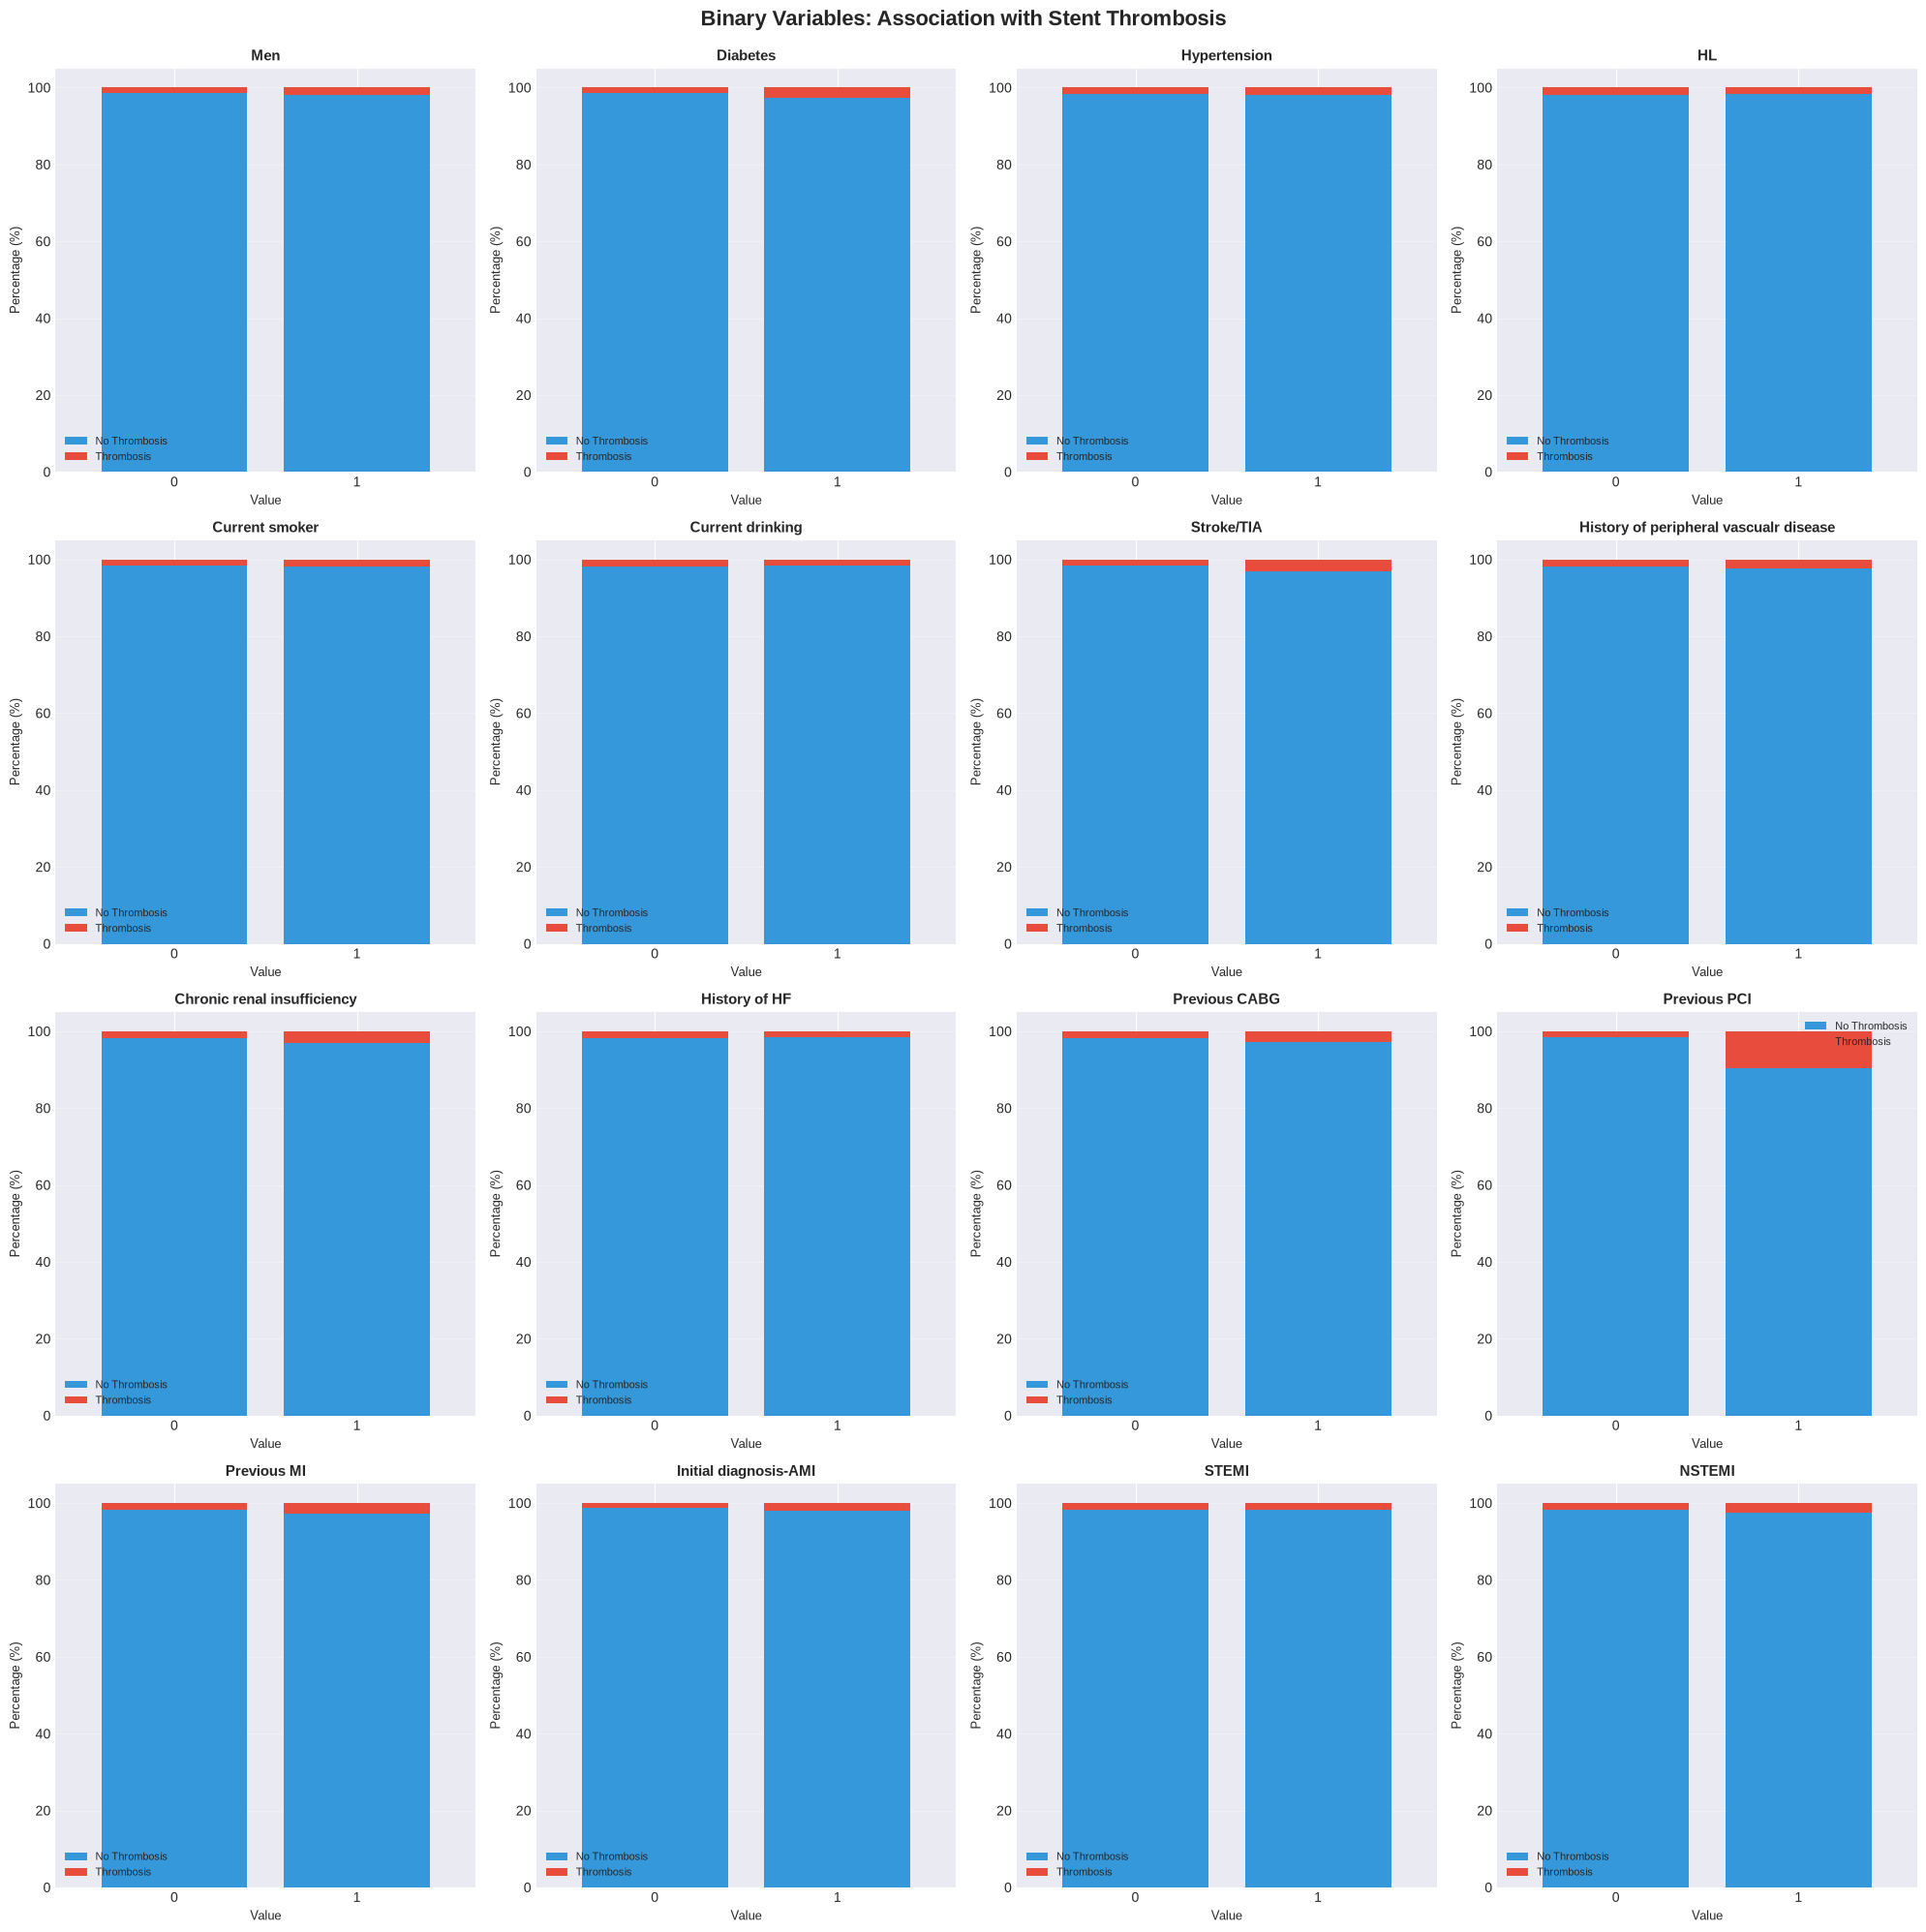

✓ Visualization saved: plots/06_binary_associations.png


In [26]:
# Binary variables association with target
if len(binary_cols) > 0:
    top_binary = binary_cols[:16]  # Top 16 binary variables

    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    axes = axes.flatten()

    for idx, col in enumerate(top_binary):
        try:
            crosstab = pd.crosstab(df[col], df[TARGET_COL], normalize="index") * 100
            crosstab.plot(
                kind="bar",
                ax=axes[idx],
                stacked=True,
                color=["#3498db", "#e74c3c"],
                width=0.8,
            )
            axes[idx].set_title(f"{col}", fontsize=11, fontweight="bold")
            axes[idx].set_xlabel("Value", fontsize=9)
            axes[idx].set_ylabel("Percentage (%)", fontsize=9)
            axes[idx].set_xticklabels(["0", "1"], rotation=0)
            axes[idx].legend(["No Thrombosis", "Thrombosis"], fontsize=8)
            axes[idx].grid(True, alpha=0.3, axis="y")
        except:
            axes[idx].axis("off")

    plt.suptitle(
        "Binary Variables: Association with Stent Thrombosis",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()
    plt.savefig(
        str(PLOT_DIR / "06_binary_associations.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("✓ Visualization saved: plots/06_binary_associations.png")

## 13. Feature Importance Summary

Combining correlation analysis and statistical significance, we can identify the most important features for predicting stent thrombosis. This comprehensive view helps prioritize features for modeling.


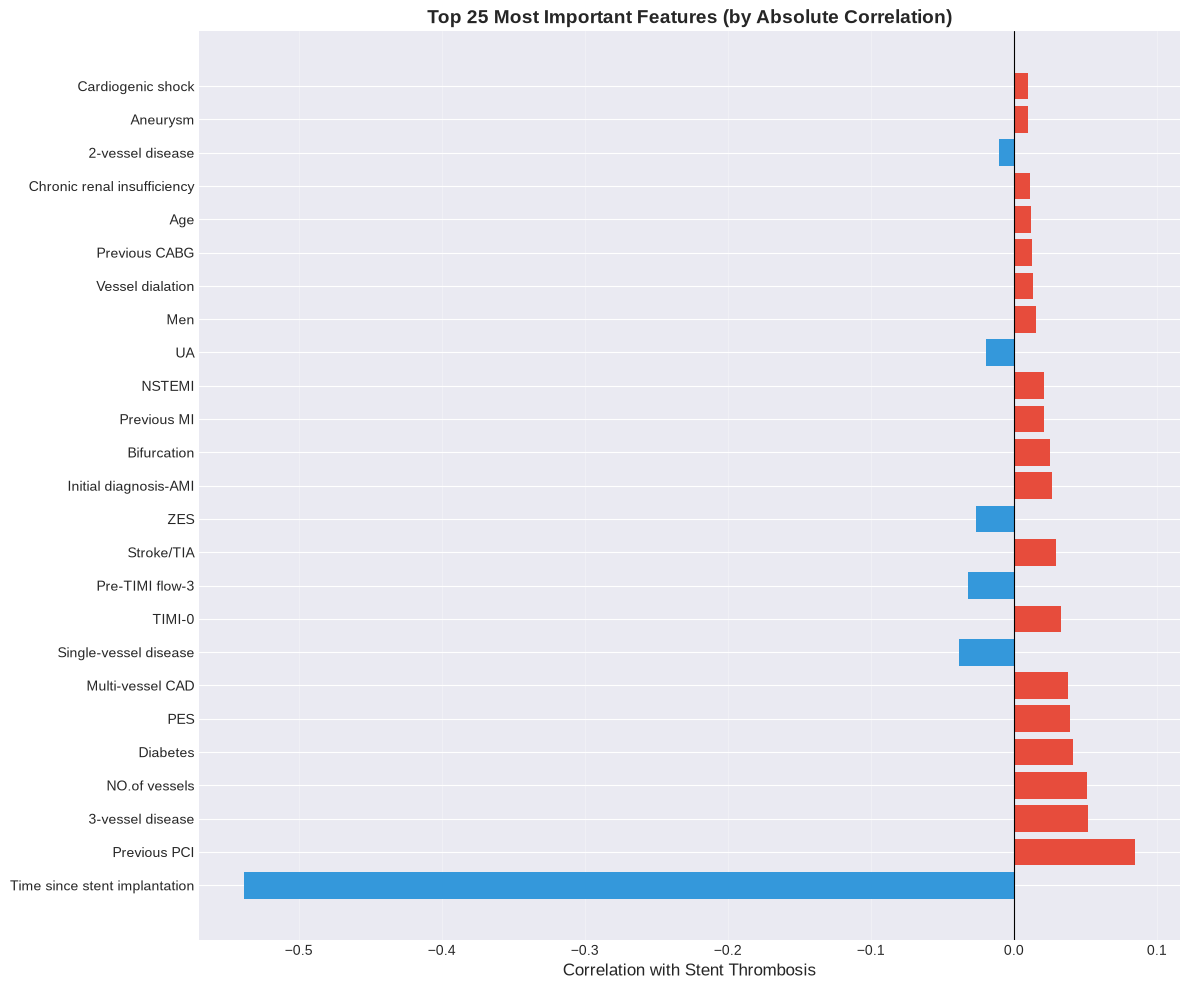

✓ Visualization saved: plots/09_feature_importance.png


In [27]:
# Feature importance summary (combined view)
if TARGET_COL in df.columns and len(correlations) > 0:
    # Create combined importance score
    importance_data = []
    for col in numeric_cols[:50]:  # Top 50 features
        try:
            corr_val = correlations.get(col, 0)
            importance_data.append(
                {
                    "Feature": col,
                    "Abs_Correlation": abs(corr_val),
                    "Correlation": corr_val,
                }
            )
        except:
            pass

    if importance_data:
        importance_df = (
            pd.DataFrame(importance_data)
            .sort_values("Abs_Correlation", ascending=False)
            .head(25)
        )

        fig, ax = plt.subplots(figsize=(12, 10))
        colors = [
            "#e74c3c" if x > 0 else "#3498db" for x in importance_df["Correlation"]
        ]
        ax.barh(range(len(importance_df)), importance_df["Correlation"], color=colors)
        ax.set_yticks(range(len(importance_df)))
        ax.set_yticklabels(importance_df["Feature"])
        ax.set_xlabel("Correlation with Stent Thrombosis", fontsize=12)
        ax.set_title(
            "Top 25 Most Important Features (by Absolute Correlation)",
            fontsize=14,
            fontweight="bold",
        )
        ax.axvline(x=0, color="black", linestyle="-", linewidth=0.8)
        ax.grid(True, alpha=0.3, axis="x")

        plt.tight_layout()
        plt.savefig(
            str(PLOT_DIR / "09_feature_importance.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()
        print("✓ Visualization saved: plots/09_feature_importance.png")

## 14. Key Insights and Summary

Let's synthesize all the findings from our analysis to extract actionable insights. This summary will help guide:
- **Feature Selection**: Which features are most predictive?
- **Data Preprocessing**: What transformations or imputations are needed?
- **Modeling Strategy**: What techniques should be considered?
- **Clinical Interpretation**: What are the key risk factors?


In [28]:
# Generate key insights
print("=" * 80)
print("KEY INSIGHTS AND SUMMARY")
print("=" * 80)

insights = []

# Target distribution insights
if imbalance_ratio < 0.3:
    insights.append(
        f"⚠ Class imbalance detected (ratio: {imbalance_ratio:.3f}). Consider using techniques like SMOTE or class weights."
    )
else:
    insights.append(
        f"✓ Class distribution is relatively balanced (ratio: {imbalance_ratio:.3f})"
    )

# Missing data insights
if len(missing_df) > 0:
    insights.append(
        f"⚠ {len(missing_df)} columns have missing values. Total missing: {missing_data.sum():,} ({missing_data.sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%)"
    )
    insights.append(
        "   Consider imputation strategies for columns with <20% missing values."
    )

# Correlation insights
if TARGET_COL in df.columns and len(correlations) > 0:
    strong_pos = correlations[correlations > 0.3]
    strong_neg = correlations[correlations < -0.3]
    if len(strong_pos) > 0:
        insights.append(
            f"✓ {len(strong_pos)} features show strong positive correlation (>0.3) with stent thrombosis"
        )
    if len(strong_neg) > 0:
        insights.append(
            f"✓ {len(strong_neg)} features show strong negative correlation (<-0.3) with stent thrombosis"
        )
    if len(strong_pos) == 0 and len(strong_neg) == 0:
        insights.append(
            "⚠ No features show strong correlation (>0.3) with target. May need feature engineering."
        )

# Statistical significance insights
if test_results:
    sig_continuous = len([r for r in test_results if r["P-value"] < 0.05])
    if sig_continuous > 0:
        insights.append(
            f"✓ {sig_continuous} continuous features show statistically significant association (p < 0.05)"
        )

if chi2_results:
    sig_binary = len([r for r in chi2_results if r["P-value"] < 0.05])
    if sig_binary > 0:
        insights.append(
            f"✓ {sig_binary} binary features show statistically significant association (p < 0.05)"
        )

# Feature count insights
insights.append(
    f"✓ Dataset contains {len(binary_cols)} binary features, {len(continuous_cols)} continuous features, and {len(categorical_cols)} categorical features"
)

print("\nKey Insights:")
for i, insight in enumerate(insights, 1):
    print(f"  {i}. {insight}")

KEY INSIGHTS AND SUMMARY

Key Insights:
  1. ⚠ Class imbalance detected (ratio: 0.018). Consider using techniques like SMOTE or class weights.
  2. ✓ 1 features show strong negative correlation (<-0.3) with stent thrombosis
  3. ✓ 12 continuous features show statistically significant association (p < 0.05)
  4. ✓ 10 binary features show statistically significant association (p < 0.05)
  5. ✓ Dataset contains 57 binary features, 24 continuous features, and 1 categorical features


In [29]:
# Top important features
if TARGET_COL in df.columns and len(correlations) > 0:
    print("\n" + "-" * 80)
    print("TOP 10 MOST IMPORTANT FEATURES (by absolute correlation)")
    print("-" * 80)
    top_features = correlations.abs().nlargest(10)
    for idx, (feature, corr) in enumerate(top_features.items(), 1):
        direction = "increases" if correlations[feature] > 0 else "decreases"
        print(
            f"  {idx:2d}. {feature:40s} | Correlation: {correlations[feature]:7.4f} | {direction} risk"
        )


--------------------------------------------------------------------------------
TOP 10 MOST IMPORTANT FEATURES (by absolute correlation)
--------------------------------------------------------------------------------
   1. Time since stent implantation            | Correlation: -0.5384 | decreases risk
   2. WBC                                      | Correlation:  0.1502 | increases risk
   3. LV                                       | Correlation:  0.1472 | increases risk
   4. eGFR                                     | Correlation: -0.0937 | decreases risk
   5. 1.1:1Post dilation                       | Correlation: -0.0893 | decreases risk
   6. No postdilation                          | Correlation:  0.0893 | increases risk
   7. Previous PCI                             | Correlation:  0.0850 | increases risk
   8. CKD90                                    | Correlation:  0.0626 | increases risk
   9. No.of stents per lesion                  | Correlation:  0.0604 | increases ri

## 15. Export Summary Statistics

Finally, let's save all the summary statistics and analysis results to CSV files for further reference and reporting.


In [ ]:
# Save correlations
print("\n" + "=" * 80)
print("SAVING SUMMARY STATISTICS")
print("=" * 80)

if TARGET_COL in df.columns:
    corr_df = pd.DataFrame(
        {
            "Feature": correlations.index,
            "Correlation": correlations.values,
            "Abs_Correlation": correlations.abs().values,
        }
    ).sort_values("Abs_Correlation", ascending=False)
    corr_df.to_csv(str(PLOT_DIR / "correlations_with_target.csv"), index=False)
    print("✓ Saved: plots/correlations_with_target.csv")

# Save statistical test results
if test_results:
    test_df = pd.DataFrame(test_results).sort_values("P-value")
    test_df.to_csv(
        str(PLOT_DIR / "statistical_tests_continuous.csv"), index=False
    )
    print("✓ Saved: plots/statistical_tests_continuous.csv")

if chi2_results:
    chi2_df = pd.DataFrame(chi2_results).sort_values("P-value")
    chi2_df.to_csv(str(PLOT_DIR / "statistical_tests_binary.csv"), index=False)
    print("✓ Saved: plots/statistical_tests_binary.csv")

# Save data summary
summary = {
    "Total_Rows": df.shape[0],
    "Total_Columns": df.shape[1],
    "Target_Class_0": target_counts.get(0, 0),
    "Target_Class_1": target_counts.get(1, 0),
    "Class_Imbalance_Ratio": imbalance_ratio,
    "Missing_Values_Total": missing_data.sum(),
    "Binary_Features": len(binary_cols),
    "Continuous_Features": len(continuous_cols),
    "Categorical_Features": len(categorical_cols),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(str(PLOT_DIR / "data_summary.csv"), index=False)

## 16. Additional Deep-Dive Analyses

Let's perform some additional analyses that provide deeper insights into the data:
- **Demographic Analysis**: Age and gender breakdowns by target
- **Categorical Variable Analysis**: Detailed analysis of stent types and other categorical features
- **Time-based Analysis**: Time since stent implantation patterns
- **Multicollinearity Check**: Identify highly correlated features that might cause redundancy
- **Distribution Shape Analysis**: Skewness and kurtosis for continuous variables


### 16.1 Demographic Analysis

Understanding how demographic factors (age, gender) relate to stent thrombosis can provide important clinical insights.


In [ ]:
# Demographic analysis
if "Age" in df.columns and "Men" in df.columns:
    print("=" * 80)
    print("DEMOGRAPHIC ANALYSIS")
    print("=" * 80)

    # Age analysis
    print("\nAge Statistics by Target:")
    age_by_target = df.groupby(TARGET_COL)["Age"].agg(
        ["mean", "median", "std", "min", "max"]
    )
    print(age_by_target.round(2))

    # Gender analysis
    print("\n\nGender Distribution by Target:")
    gender_crosstab = pd.crosstab(df["Men"], df[TARGET_COL], margins=True)
    print(gender_crosstab)
    print("\nGender Distribution (Percentages):")
    gender_pct = pd.crosstab(df["Men"], df[TARGET_COL], normalize="index") * 100
    print(gender_pct.round(2))

    # Visualize demographics
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Age distribution by target
    for target_val in [0, 1]:
        data = df[df[TARGET_COL] == target_val]["Age"].dropna()
        axes[0, 0].hist(data, alpha=0.6, label=f"Class {target_val}", bins=30)
    axes[0, 0].set_title(
        "Age Distribution by Stent Thrombosis", fontsize=12, fontweight="bold"
    )
    axes[0, 0].set_xlabel("Age", fontsize=11)
    axes[0, 0].set_ylabel("Frequency", fontsize=11)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Age box plot
    sns.boxplot(data=df, x=TARGET_COL, y="Age", ax=axes[0, 1])
    axes[0, 1].set_title("Age by Stent Thrombosis", fontsize=12, fontweight="bold")
    axes[0, 1].set_xlabel("Stent Thrombosis", fontsize=11)
    axes[0, 1].set_ylabel("Age", fontsize=11)
    axes[0, 1].set_xticklabels(["No (0)", "Yes (1)"])

    # Gender distribution
    gender_target = pd.crosstab(df["Men"], df[TARGET_COL])
    gender_target.plot(kind="bar", ax=axes[1, 0], color=["#3498db", "#e74c3c"])
    axes[1, 0].set_title(
        "Gender Distribution by Stent Thrombosis", fontsize=12, fontweight="bold"
    )
    axes[1, 0].set_xlabel("Gender (0=Women, 1=Men)", fontsize=11)
    axes[1, 0].set_ylabel("Count", fontsize=11)
    axes[1, 0].legend(["No Thrombosis", "Thrombosis"])
    axes[1, 0].set_xticklabels(["Women", "Men"], rotation=0)
    axes[1, 0].grid(True, alpha=0.3, axis="y")

    # Age groups analysis
    df["Age_Group"] = pd.cut(
        df["Age"], bins=[0, 50, 60, 70, 100], labels=["<50", "50-60", "60-70", "70+"]
    )
    age_group_crosstab = (
            pd.crosstab(df["Age_Group"], df[TARGET_COL], normalize="index") * 100
    )
    age_group_crosstab.plot(kind="bar", ax=axes[1, 1], color=["#3498db", "#e74c3c"])
    axes[1, 1].set_title(
        "Stent Thrombosis by Age Group", fontsize=12, fontweight="bold"
    )
    axes[1, 1].set_xlabel("Age Group", fontsize=11)
    axes[1, 1].set_ylabel("Percentage (%)", fontsize=11)
    axes[1, 1].legend(["No Thrombosis", "Thrombosis"])
    axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha="right")
    axes[1, 1].grid(True, alpha=0.3, axis="y")

    plt.suptitle(
        "Demographic Analysis: Age and Gender by Stent Thrombosis",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()
    plt.savefig(
        str(PLOT_DIR / "10_demographic_analysis.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("\n✓ Visualization saved: plots/10_demographic_analysis.png")

    # Clean up temporary column
    df.drop("Age_Group", axis=1, inplace=True)

### 16.2 Categorical Variable Analysis

Let's analyze categorical variables like stent types to understand their distribution and relationship with the target.


In [ ]:
# Categorical variable analysis
if len(categorical_cols) > 0:
    print("=" * 80)
    print("CATEGORICAL VARIABLE ANALYSIS")
    print("=" * 80)

    for col in categorical_cols:
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        print("  Most common values:")
        value_counts = df[col].value_counts().head(10)
        for val, count in value_counts.items():
            pct = (count / len(df)) * 100
            print(f"    {val}: {count} ({pct:.2f}%)")

        # Analyze relationship with target
        if (
                df[col].nunique() <= 20
        ):  # Only for variables with reasonable number of categories
            print("\n  Relationship with Stent Thrombosis:")
            crosstab = pd.crosstab(df[col], df[TARGET_COL], normalize="index") * 100
            print(crosstab.round(2))

            # Statistical test if binary
            if df[col].nunique() == 2:
                try:
                    contingency = pd.crosstab(df[col], df[TARGET_COL])
                    if contingency.shape == (2, 2) and contingency.min().min() > 0:
                        chi2, p_value, dof, expected = chi2_contingency(contingency)
                        print(f"  Chi-square test: p-value = {p_value:.4f}")
                except:
                    pass
        print("-" * 80)

### 17.3 Time-Based Analysis

"Time since stent implantation" is a critical feature. Let's analyze how time patterns relate to stent thrombosis.


In [ ]:
# Time-based analysis
time_col = "Time since stent implantation"
if time_col in df.columns:
    print("=" * 80)
    print("TIME-BASED ANALYSIS")
    print("=" * 80)

    # Convert to years for easier interpretation
    df["Time_years"] = df[time_col] / 365.25

    print("\nTime since stent implantation statistics:")
    print(
        f"  Mean: {df[time_col].mean():.1f} days ({df['Time_years'].mean():.2f} years)"
    )
    print(
        f"  Median: {df[time_col].median():.1f} days ({df['Time_years'].median():.2f} years)"
    )
    print(f"  Min: {df[time_col].min():.1f} days ({df['Time_years'].min():.2f} years)")
    print(f"  Max: {df[time_col].max():.1f} days ({df['Time_years'].max():.2f} years)")

    print("\nTime statistics by Target:")
    time_by_target = df.groupby(TARGET_COL)[time_col].agg(
        ["mean", "median", "std", "min", "max"]
    )
    print(time_by_target.round(2))

    # Create time groups
    df["Time_Group"] = pd.cut(
        df["Time_years"],
        bins=[0, 1, 2, 5, 10, 100],
        labels=["<1yr", "1-2yr", "2-5yr", "5-10yr", "10+yr"],
    )

    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Distribution by target
    for target_val in [0, 1]:
        data = df[df[TARGET_COL] == target_val]["Time_years"].dropna()
        axes[0, 0].hist(data, alpha=0.6, label=f"Class {target_val}", bins=50)
    axes[0, 0].set_title(
        "Time Since Stent Implantation by Target", fontsize=12, fontweight="bold"
    )
    axes[0, 0].set_xlabel("Time (Years)", fontsize=11)
    axes[0, 0].set_ylabel("Frequency", fontsize=11)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Box plot
    sns.boxplot(data=df, x=TARGET_COL, y="Time_years", ax=axes[0, 1])
    axes[0, 1].set_title(
        "Time Since Implantation by Target", fontsize=12, fontweight="bold"
    )
    axes[0, 1].set_xlabel("Stent Thrombosis", fontsize=11)
    axes[0, 1].set_ylabel("Time (Years)", fontsize=11)
    axes[0, 1].set_xticklabels(["No (0)", "Yes (1)"])

    # Time groups
    time_group_crosstab = (
            pd.crosstab(df["Time_Group"], df[TARGET_COL], normalize="index") * 100
    )
    time_group_crosstab.plot(kind="bar", ax=axes[1, 0], color=["#3498db", "#e74c3c"])
    axes[1, 0].set_title(
        "Stent Thrombosis by Time Since Implantation", fontsize=12, fontweight="bold"
    )
    axes[1, 0].set_xlabel("Time Group", fontsize=11)
    axes[1, 0].set_ylabel("Percentage (%)", fontsize=11)
    axes[1, 0].legend(["No Thrombosis", "Thrombosis"])
    axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha="right")
    axes[1, 0].grid(True, alpha=0.3, axis="y")

    # Cumulative distribution
    for target_val in [0, 1]:
        data = df[df[TARGET_COL] == target_val]["Time_years"].dropna().sort_values()
        axes[1, 1].plot(
            data,
            np.arange(len(data)) / len(data),
            label=f"Class {target_val}",
            linewidth=2,
        )
    axes[1, 1].set_title(
        "Cumulative Distribution of Time", fontsize=12, fontweight="bold"
    )
    axes[1, 1].set_xlabel("Time (Years)", fontsize=11)
    axes[1, 1].set_ylabel("Cumulative Probability", fontsize=11)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(
        "Time-Based Analysis: Stent Implantation to Thrombosis",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()
    plt.savefig(
        str(PLOT_DIR / "11_time_analysis.png"), dpi=300, bbox_inches="tight"
    )
    plt.show()
    print("\n✓ Visualization saved: plots/11_time_analysis.png")

    # Clean up temporary columns
    df.drop(["Time_years", "Time_Group"], axis=1, inplace=True)

### 17.4 Medicine Use After One Year

Antiplatelet therapy is recorded as binary indicators (`Aspirin`, `Clopidogrel`, `Ticagrelor`, `DAPT`). Here we summarize which medicines were used and how many patients received each regimen among patients with at least one year of follow-up since stent implantation.


In [ ]:
# Medicine distribution among patients with >= 1 year follow-up
time_col = "Time since stent implantation"
medicine_cols = ["Aspirin", "Clopidogrel", "Ticagrelor", "DAPT"]
one_year_days = 365

if time_col in df.columns and all(col in df.columns for col in medicine_cols):
    print("=" * 80)
    print("MEDICINE USE AFTER ONE YEAR")
    print("=" * 80)

    df_after_1y = df[df[time_col] >= one_year_days].copy()
    n_after_1y = len(df_after_1y)

    print(f"\nPatients with >= 1 year follow-up: {n_after_1y:,} / {len(df):,}")
    print(
        f"Follow-up range in this group: {df_after_1y[time_col].min():.0f} to "
        f"{df_after_1y[time_col].max():.0f} days"
    )

    # Individual medicine usage counts
    med_counts = (
        df_after_1y[medicine_cols]
        .sum()
        .astype(int)
        .rename("Patients on medicine")
        .to_frame()
    )
    med_counts["Patients not on medicine"] = n_after_1y - med_counts["Patients on medicine"]
    med_counts["Percentage on medicine"] = (
            med_counts["Patients on medicine"] / n_after_1y * 100
    ).round(2)

    print("\nIndividual medicine usage:")
    display(med_counts)


    # Combination regimens
    def medicine_regimen(row):
        active = [col for col in medicine_cols if row[col] == 1]
        return " + ".join(active) if active else "No antiplatelet medicine"


    regimen_counts = (
        df_after_1y[medicine_cols]
        .apply(medicine_regimen, axis=1)
        .value_counts()
        .rename_axis("Medicine regimen")
        .reset_index(name="Number of patients")
    )
    regimen_counts["Percentage of patients"] = (
            regimen_counts["Number of patients"] / n_after_1y * 100
    ).round(2)

    print("\nMedicine regimen distribution:")
    display(regimen_counts)

    # Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    med_plot = med_counts["Patients on medicine"].sort_values(ascending=True)
    axes[0].barh(med_plot.index, med_plot.values, color="#2ecc71")
    axes[0].set_title(
        "Patients on Each Medicine (>= 1 Year Follow-up)",
        fontsize=14,
        fontweight="bold",
    )
    axes[0].set_xlabel("Number of patients", fontsize=12)
    axes[0].grid(True, alpha=0.3, axis="x")
    for i, value in enumerate(med_plot.values):
        axes[0].text(value + 20, i, f"{value:,}", va="center", fontsize=10)

    regimen_plot = regimen_counts.sort_values("Number of patients", ascending=True)
    axes[1].barh(
        regimen_plot["Medicine regimen"],
        regimen_plot["Number of patients"],
        color="#3498db",
    )
    axes[1].set_title(
        "Medicine Regimen Distribution (>= 1 Year Follow-up)",
        fontsize=14,
        fontweight="bold",
    )
    axes[1].set_xlabel("Number of patients", fontsize=12)
    axes[1].grid(True, alpha=0.3, axis="x")
    for i, value in enumerate(regimen_plot["Number of patients"].values):
        axes[1].text(value + 20, i, f"{value:,}", va="center", fontsize=10)

    plt.tight_layout()
    plt.savefig(
        str(PLOT_DIR / "13_medicine_use_after_one_year.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("✓ Visualization saved: plots/13_medicine_use_after_one_year.png")

    med_counts.to_csv(
        str(PLOT_DIR / "medicine_use_after_one_year_individual.csv")
    )
    regimen_counts.to_csv(
        str(PLOT_DIR / "medicine_use_after_one_year_regimens.csv"),
        index=False,
    )
    print("✓ Saved: plots/medicine_use_after_one_year_individual.csv")
    print("✓ Saved: plots/medicine_use_after_one_year_regimens.csv")
else:
    missing = [col for col in [time_col] + medicine_cols if col not in df.columns]
    print(f"Missing required columns for medicine analysis: {missing}")


### 17.5 Medicine Use vs Stent Thrombosis (VLST)

Compare antiplatelet medicine use between patients with and without stent thrombosis, then examine the stent thrombosis rate within each medicine-consuming subgroup.


In [ ]:
# Medicine consumption distribution by stent thrombosis outcome
medicine_cols = ["Aspirin", "Clopidogrel", "Ticagrelor", "DAPT"]
medicine_display_cols = medicine_cols + ["No antiplatelet medicine"]

if TARGET_COL in df.columns and all(col in df.columns for col in medicine_cols):
    print("=" * 80)
    print("MEDICINE USE BY STENT THROMBOSIS OUTCOME")
    print("=" * 80)

    df = df.copy()
    df["No antiplatelet medicine"] = (df[medicine_cols].sum(axis=1) == 0).astype(int)

    outcome_labels = {
        1: "Stent thrombosis (VLST)",
        0: "No stent thrombosis",
    }

    med_by_outcome = []
    for outcome_value, outcome_label in outcome_labels.items():
        group = df[df[TARGET_COL] == outcome_value]
        group_size = len(group)

        for med in medicine_display_cols:
            on_med = int(group[med].sum())
            med_by_outcome.append(
                {
                    "Outcome": outcome_label,
                    "Medicine": med,
                    "Patients on medicine": on_med,
                    "Patients not on medicine": group_size - on_med,
                    "Percentage on medicine": round(on_med / group_size * 100, 2),
                }
            )

    med_by_outcome_df = pd.DataFrame(med_by_outcome)
    print("\nMedicine use by outcome (includes patients on no antiplatelet medicine):")
    display(med_by_outcome_df)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    colors = ["#e74c3c", "#3498db"]

    for ax, (outcome_value, outcome_label), color in zip(
            axes, outcome_labels.items(), colors
    ):
        subset = med_by_outcome_df[med_by_outcome_df["Outcome"] == outcome_label]
        bars = ax.bar(
            subset["Medicine"],
            subset["Patients on medicine"],
            color=color,
            alpha=0.85,
        )
        ax.set_title(outcome_label, fontsize=13, fontweight="bold")
        ax.set_xlabel("Medicine / regimen status", fontsize=12)
        ax.set_ylabel("Number of patients", fontsize=12)
        ax.tick_params(axis="x", rotation=20)
        ax.grid(True, alpha=0.3, axis="y")
        ymax = subset["Patients on medicine"].max()
        for bar, pct in zip(bars, subset["Percentage on medicine"]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ymax * 0.02,
                f"{int(bar.get_height()):,}\n({pct:.1f}%)",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    fig.suptitle(
        "Medicine Consumption Among Patients With vs Without Stent Thrombosis",
        fontsize=15,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig(
        str(PLOT_DIR / "14_medicine_use_by_vlst_outcome.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("✓ Visualization saved: plots/14_medicine_use_by_vlst_outcome.png")

    med_by_outcome_df.to_csv(
        str(PLOT_DIR / "medicine_use_by_vlst_outcome.csv"), index=False
    )
    print("✓ Saved: plots/medicine_use_by_vlst_outcome.csv")
else:
    missing = [col for col in [TARGET_COL] + medicine_cols if col not in df.columns]
    print(f"Missing required columns: {missing}")


In [ ]:
# Stent thrombosis rate among patients on each medicine (including no medicine)
medicine_cols = ["Aspirin", "Clopidogrel", "Ticagrelor", "DAPT"]
medicine_display_cols = medicine_cols + ["No antiplatelet medicine"]

if TARGET_COL in df.columns and all(col in df.columns for col in medicine_cols):
    if "No antiplatelet medicine" not in df.columns:
        df["No antiplatelet medicine"] = (df[medicine_cols].sum(axis=1) == 0).astype(int)

    print("=" * 80)
    print("STENT THROMBOSIS RATE BY MEDICINE CONSUMPTION")
    print("=" * 80)

    vlst_by_medicine = []
    for med in medicine_display_cols:
        on_med = df[df[med] == 1]
        off_med = df[df[med] == 0]

        vlst_on = int(on_med[TARGET_COL].sum())
        vlst_off = int(off_med[TARGET_COL].sum())

        vlst_by_medicine.append(
            {
                "Medicine": med,
                "Patients on medicine": len(on_med),
                "VLST cases on medicine": vlst_on,
                "VLST rate on medicine (%)": round(vlst_on / len(on_med) * 100, 2),
                "Patients not on medicine": len(off_med),
                "VLST cases not on medicine": vlst_off,
                "VLST rate not on medicine (%)": round(vlst_off / len(off_med) * 100, 2),
            }
        )

    vlst_by_medicine_df = pd.DataFrame(vlst_by_medicine)
    print("\nVLST rate by medicine consumption:")
    display(vlst_by_medicine_df)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    bars_on = axes[0].bar(
        vlst_by_medicine_df["Medicine"],
        vlst_by_medicine_df["VLST rate on medicine (%)"],
        color="#e67e22",
        alpha=0.9,
    )
    axes[0].set_title(
        "VLST Rate Among Patients on Each Medicine / No-Medicine Group",
        fontsize=13,
        fontweight="bold",
    )
    axes[0].set_xlabel("Medicine / regimen status", fontsize=12)
    axes[0].set_ylabel("VLST rate (%)", fontsize=12)
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].grid(True, alpha=0.3, axis="y")
    for i, bar in enumerate(bars_on):
        row = vlst_by_medicine_df.iloc[i]
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f"{int(row['VLST cases on medicine'])}/{int(row['Patients on medicine'])}\n"
            f"({row['VLST rate on medicine (%)']:.2f}%)",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    x = np.arange(len(medicine_display_cols))
    width = 0.35
    axes[1].bar(
        x - width / 2,
        vlst_by_medicine_df["VLST rate on medicine (%)"],
        width,
        label="On medicine / no-medicine group",
        color="#e67e22",
    )
    axes[1].bar(
        x + width / 2,
        vlst_by_medicine_df["VLST rate not on medicine (%)"],
        width,
        label="Not in that group",
        color="#95a5a6",
    )
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(medicine_display_cols, rotation=20, ha="right")
    axes[1].set_title(
        "VLST Rate: In Group vs Not in Group",
        fontsize=13,
        fontweight="bold",
    )
    axes[1].set_xlabel("Medicine / regimen status", fontsize=12)
    axes[1].set_ylabel("VLST rate (%)", fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis="y")

    fig.suptitle(
        "Stent Thrombosis Distribution by Medicine Consumption",
        fontsize=15,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig(
        str(PLOT_DIR / "15_vlst_rate_by_medicine_consumption.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("✓ Visualization saved: plots/15_vlst_rate_by_medicine_consumption.png")

    vlst_by_medicine_df.to_csv(
        str(PLOT_DIR / "vlst_rate_by_medicine_consumption.csv"), index=False
    )
    print("✓ Saved: plots/vlst_rate_by_medicine_consumption.csv")
else:
    missing = [col for col in [TARGET_COL] + medicine_cols if col not in df.columns]
    print(f"Missing required columns: {missing}")


### 17.6 Statistical Association: Medicine Use and VLST

Both **medicine use** and **stent thrombosis** are binary variables, so the appropriate primary tests are **2×2 association tests**:

- **Chi-square test of independence**: tests whether medicine status and VLST are associated in a contingency table. It is appropriate here because both variables are categorical and we compare group proportions.
- **Fisher's exact test**: preferred when any expected cell count is small (often < 5), which is common for rare medicines such as Ticagrelor. Fisher's exact is more reliable than chi-square in sparse tables.
- **Odds ratio (OR)**: quantifies effect size. OR > 1 means higher odds of VLST in the medicine-taking group; OR < 1 means lower odds.

**Why not other tests?**
- *t-test / Mann-Whitney*: for comparing continuous outcomes, not binary medicine vs binary VLST.
- *Correlation (Pearson/Spearman)*: measures linear/monotonic association between numeric variables; less interpretable for two binary variables than OR + Fisher/chi-square.
- *Logistic regression*: useful for multivariable adjustment (confounders), but univariate 2×2 tests are the correct first step for this EDA question.

**Important caveat:** these are observational associations, not causal effects. Medicine prescribing may be related to patient risk profile, so significant results should be interpreted as hypothesis-generating.


STATISTICAL ASSOCIATION: MEDICINE USE vs VLST

Univariate association tests (medicine vs VLST):


,Medicine,VLST on medicine,No VLST on medicine,VLST not on medicine,No VLST not on medicine,VLST rate on medicine (%),VLST rate not on medicine (%),Odds ratio,Chi-square p-value,Fisher p-value,Test used,P-value,Significant (p < 0.05)
1,Clopidogrel,28,2368,64,2725,1.17,2.29,0.503,0.003109,0.002133,Chi-square,0.003109,Yes
0,Aspirin,45,3148,47,1945,1.41,2.36,0.592,0.015844,0.012886,Chi-square,0.015844,Yes
4,No antiplatelet medicine,41,1747,51,3346,2.29,1.50,1.540,0.052142,0.046083,Chi-square,0.052142,No
3,DAPT,35,2260,57,2833,1.53,1.97,0.770,0.268807,0.244929,Chi-square,0.268807,No
2,Ticagrelor,1,90,91,5003,1.10,1.79,0.611,0.926815,1.000000,Fisher's exact,1.000000,No



--------------------------------------------------------------------------------
INTERPRETATION FROM CHARTS + STATISTICAL TESTS
--------------------------------------------------------------------------------

Medicines with statistically significant univariate association (p < 0.05):
  - Clopidogrel: OR=0.503, p=0.0031 (Chi-square) -> lower VLST odds in the 'on/group' category
  - Aspirin: OR=0.592, p=0.0158 (Chi-square) -> lower VLST odds in the 'on/group' category

Still significant after Bonferroni correction (p < 0.0100): Clopidogrel

Clinical reading:
  - Aspirin and Clopidogrel show lower VLST rates among users in the descriptive charts.
  - 'No antiplatelet medicine' patients have a higher VLST rate than patients on any medicine.
  - Ticagrelor has very few users/events, so it is underpowered and not reliable for strong conclusions.
  - DAPT alone does not show a clear univariate association with VLST in this dataset.
  - These patterns are associative; causal interpretation r

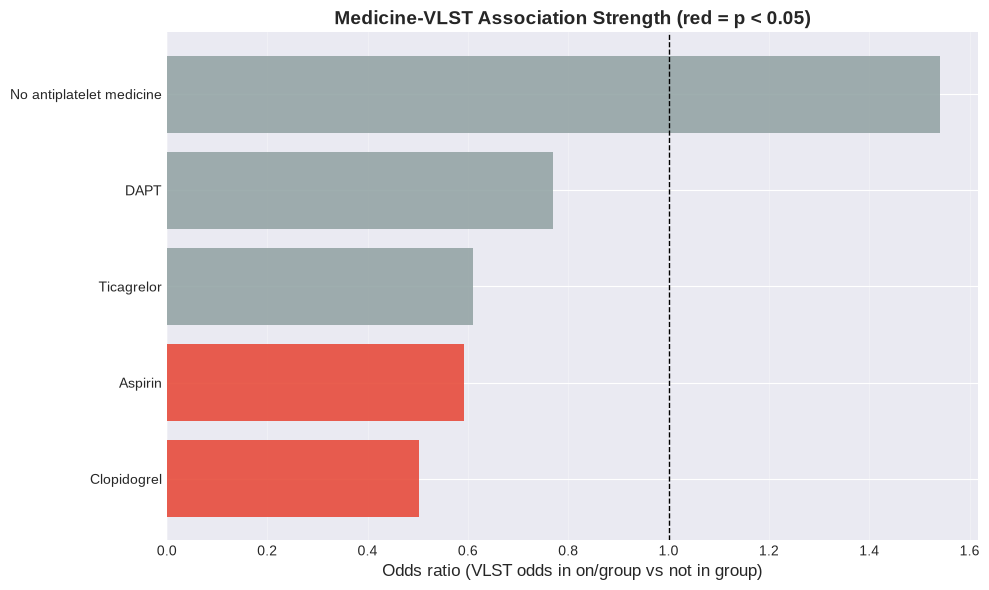

✓ Visualization saved: plots/16_medicine_vlst_odds_ratios.png
✓ Saved: plots/medicine_vlst_statistical_tests.csv


In [37]:
# Statistical tests for medicine-VLST association
from scipy.stats import chi2_contingency, fisher_exact

medicine_cols = ["Aspirin", "Clopidogrel", "Ticagrelor", "DAPT"]
medicine_display_cols = medicine_cols + ["No antiplatelet medicine"]

if TARGET_COL in df.columns and all(col in df.columns for col in medicine_cols):
    if "No antiplatelet medicine" not in df.columns:
        df["No antiplatelet medicine"] = (df[medicine_cols].sum(axis=1) == 0).astype(int)

    print("=" * 80)
    print("STATISTICAL ASSOCIATION: MEDICINE USE vs VLST")
    print("=" * 80)

    stat_rows = []
    for med in medicine_display_cols:
        contingency = pd.crosstab(df[med], df[TARGET_COL])
        # Ensure 2x2 layout: rows = medicine off/on, cols = no VLST / VLST
        a = int(contingency.loc[1, 1]) if (1 in contingency.index and 1 in contingency.columns) else 0
        b = int(contingency.loc[1, 0]) if (1 in contingency.index and 0 in contingency.columns) else 0
        c = int(contingency.loc[0, 1]) if (0 in contingency.index and 1 in contingency.columns) else 0
        d = int(contingency.loc[0, 0]) if (0 in contingency.index and 0 in contingency.columns) else 0
        table = np.array([[a, b], [c, d]])

        chi2, chi2_p, dof, expected = chi2_contingency(table)
        odds_ratio, fisher_p = fisher_exact(table, alternative="two-sided")
        min_expected = expected.min()

        if min_expected < 5:
            test_used = "Fisher's exact"
            p_value = fisher_p
        else:
            test_used = "Chi-square"
            p_value = chi2_p

        vlst_rate_on = round(a / (a + b) * 100, 2) if (a + b) > 0 else np.nan
        vlst_rate_off = round(c / (c + d) * 100, 2) if (c + d) > 0 else np.nan

        stat_rows.append(
            {
                "Medicine": med,
                "VLST on medicine": a,
                "No VLST on medicine": b,
                "VLST not on medicine": c,
                "No VLST not on medicine": d,
                "VLST rate on medicine (%)": vlst_rate_on,
                "VLST rate not on medicine (%)": vlst_rate_off,
                "Odds ratio": round(odds_ratio, 3),
                "Chi-square p-value": round(chi2_p, 6),
                "Fisher p-value": round(fisher_p, 6),
                "Test used": test_used,
                "P-value": round(p_value, 6),
                "Significant (p < 0.05)": "Yes" if p_value < 0.05 else "No",
            }
        )

    med_vlst_stats_df = pd.DataFrame(stat_rows).sort_values("P-value")
    print("\nUnivariate association tests (medicine vs VLST):")
    display(med_vlst_stats_df)

    # Bonferroni-adjusted significance across 5 tests
    alpha = 0.05
    bonferroni_alpha = alpha / len(medicine_display_cols)
    med_vlst_stats_df["Bonferroni significant"] = med_vlst_stats_df["P-value"] < bonferroni_alpha

    significant = med_vlst_stats_df[med_vlst_stats_df["P-value"] < alpha]
    bonf_significant = med_vlst_stats_df[med_vlst_stats_df["Bonferroni significant"]]

    print("\n" + "-" * 80)
    print("INTERPRETATION FROM CHARTS + STATISTICAL TESTS")
    print("-" * 80)

    if len(significant) > 0:
        print(f"\nMedicines with statistically significant univariate association (p < {alpha}):")
        for _, row in significant.iterrows():
            direction = "higher" if row["Odds ratio"] > 1 else "lower"
            print(
                f"  - {row['Medicine']}: OR={row['Odds ratio']:.3f}, p={row['P-value']:.4f} "
                f"({row['Test used']}) -> {direction} VLST odds in the 'on/group' category"
            )
    else:
        print("\nNo medicine showed a statistically significant univariate association at p < 0.05.")

    if len(bonf_significant) > 0:
        print(
            f"\nStill significant after Bonferroni correction (p < {bonferroni_alpha:.4f}): "
            f"{', '.join(bonf_significant['Medicine'].tolist())}"
        )
    else:
        print(
            f"\nAfter Bonferroni correction (p < {bonferroni_alpha:.4f}), no medicine remains significant."
        )

    print(
        "\nClinical reading:"
        "\n  - Aspirin and Clopidogrel show lower VLST rates among users in the descriptive charts."
        "\n  - 'No antiplatelet medicine' patients have a higher VLST rate than patients on any medicine."
        "\n  - Ticagrelor has very few users/events, so it is underpowered and not reliable for strong conclusions."
        "\n  - DAPT alone does not show a clear univariate association with VLST in this dataset."
        "\n  - These patterns are associative; causal interpretation requires adjusted modeling."
    )

    # Visualization: odds ratios with reference line OR=1
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_df = med_vlst_stats_df.sort_values("Odds ratio")
    colors = ["#e74c3c" if p < alpha else "#95a5a6" for p in plot_df["P-value"]]
    ax.barh(plot_df["Medicine"], plot_df["Odds ratio"], color=colors, alpha=0.9)
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Odds ratio (VLST odds in on/group vs not in group)", fontsize=12)
    ax.set_title(
        "Medicine-VLST Association Strength (red = p < 0.05)",
        fontsize=14,
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(
        str(PLOT_DIR / "16_medicine_vlst_odds_ratios.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("✓ Visualization saved: plots/16_medicine_vlst_odds_ratios.png")

    med_vlst_stats_df.to_csv(
        str(PLOT_DIR / "medicine_vlst_statistical_tests.csv"), index=False
    )
    print("✓ Saved: plots/medicine_vlst_statistical_tests.csv")
else:
    missing = [col for col in [TARGET_COL] + medicine_cols if col not in df.columns]
    print(f"Missing required columns: {missing}")


### 16.4 Multicollinearity Analysis

High correlations between features can indicate redundancy and may cause issues in modeling. Let's identify highly correlated feature pairs.


MULTICOLLINEARITY ANALYSIS

⚠ Found 4 highly correlated feature pairs (|r| > 0.7):

Top 20 highly correlated pairs:


,Feature 1,Feature 2,Correlation
0,Min-stent diameter,Max-stent diameter,0.904075
2,TCL,LDL,0.878888
1,Total stent length,No.of stents per lesion,0.863269
3,Fast-Glu,HbA1c,0.761349


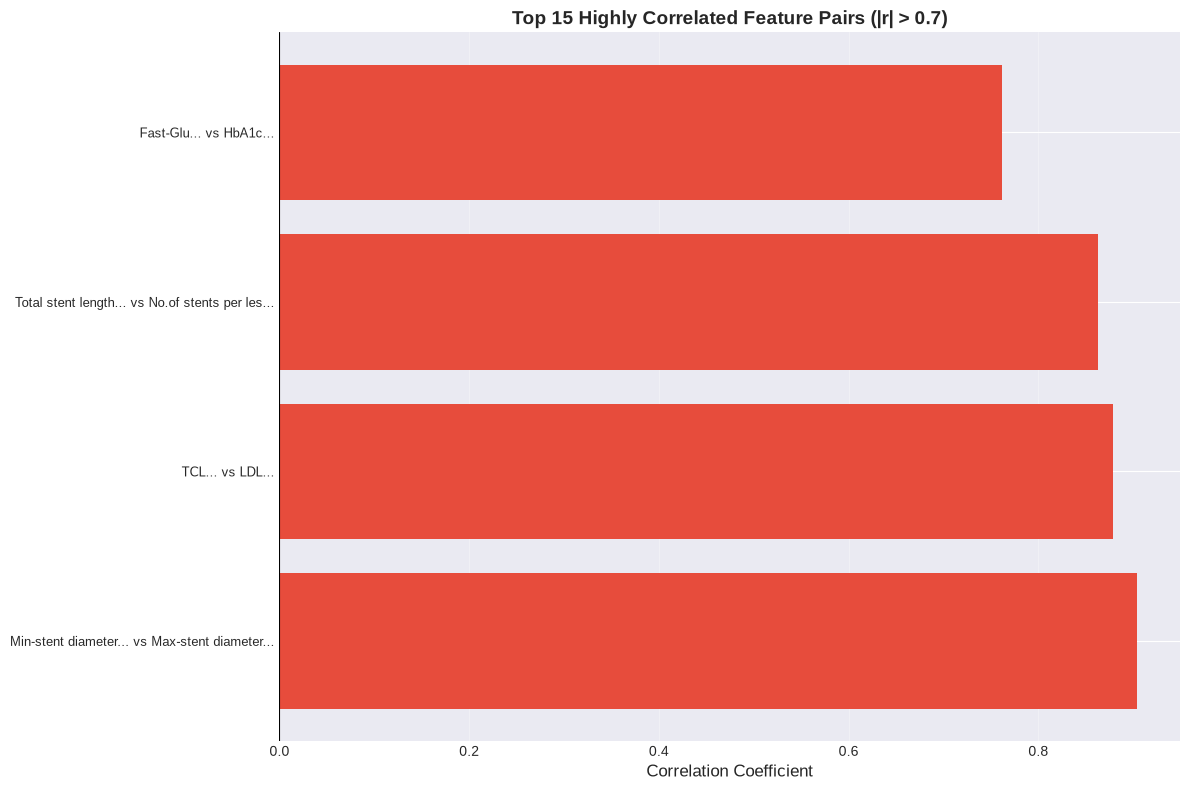


✓ Visualization saved: plots/12_multicollinearity.png


In [38]:
# Multicollinearity analysis
if len(continuous_cols) > 0:
    print("=" * 80)
    print("MULTICOLLINEARITY ANALYSIS")
    print("=" * 80)

    # Calculate correlation matrix for continuous variables
    corr_matrix = df[continuous_cols].corr()

    # Find highly correlated pairs (excluding diagonal and duplicates)
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:  # Threshold for high correlation
                high_corr_pairs.append(
                    {
                        "Feature 1": corr_matrix.columns[i],
                        "Feature 2": corr_matrix.columns[j],
                        "Correlation": corr_val,
                    }
                )

    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
            "Correlation", key=abs, ascending=False
        )
        print(
            f"\n⚠ Found {len(high_corr_pairs)} highly correlated feature pairs (|r| > 0.7):"
        )
        print("\nTop 20 highly correlated pairs:")
        display(high_corr_df.head(20))

        # Visualize top correlations
        if len(high_corr_pairs) > 0:
            top_pairs = high_corr_df.head(15)
            fig, ax = plt.subplots(figsize=(12, 8))
            y_pos = np.arange(len(top_pairs))
            colors = [
                "#e74c3c" if x > 0 else "#3498db" for x in top_pairs["Correlation"]
            ]
            ax.barh(y_pos, top_pairs["Correlation"], color=colors)
            ax.set_yticks(y_pos)
            ax.set_yticklabels(
                [
                    f"{row['Feature 1'][:20]}... vs {row['Feature 2'][:20]}..."
                    for _, row in top_pairs.iterrows()
                ],
                fontsize=9,
            )
            ax.set_xlabel("Correlation Coefficient", fontsize=12)
            ax.set_title(
                "Top 15 Highly Correlated Feature Pairs (|r| > 0.7)",
                fontsize=14,
                fontweight="bold",
            )
            ax.axvline(x=0, color="black", linestyle="-", linewidth=0.8)
            ax.grid(True, alpha=0.3, axis="x")
            plt.tight_layout()
            plt.savefig(
                str(PLOT_DIR / "12_multicollinearity.png"),
                dpi=300,
                bbox_inches="tight",
            )
            plt.show()
            print("\n✓ Visualization saved: plots/12_multicollinearity.png")
    else:
        print("\n✓ No highly correlated feature pairs found (|r| > 0.7)")
        print("  This suggests low multicollinearity, which is good for modeling.")

### 16.5 Distribution Shape Analysis

Understanding the shape of distributions (skewness and kurtosis) helps determine if transformations are needed for modeling.


DISTRIBUTION SHAPE ANALYSIS

Distribution Shape Statistics (Top 20 by absolute skewness):


,Feature,Skewness,Kurtosis,Abs_Skewness,Interpretation_Skew,Interpretation_Kurt
14,Cre,7.484056,161.335262,7.484056,Highly Skewed,Heavy Tailed
10,CaI,2.834164,9.432386,2.834164,Highly Skewed,Heavy Tailed
16,CKD5,2.617650,7.507913,2.617650,Highly Skewed,Heavy Tailed
21,Fast-Glu,2.417145,7.838604,2.417145,Highly Skewed,Heavy Tailed
1,Time since stent implantation,-2.359276,13.211717,2.359276,Highly Skewed,Heavy Tailed
20,TG,2.134846,8.837294,2.134846,Highly Skewed,Heavy Tailed
7,No.of stents per lesion,2.131825,4.700423,2.131825,Highly Skewed,Heavy Tailed
5,Total stent length,1.737190,4.154201,1.737190,Highly Skewed,Heavy Tailed
23,Fiberinogen,1.621689,5.653460,1.621689,Highly Skewed,Heavy Tailed
9,LVEF,-1.482588,7.416341,1.482588,Highly Skewed,Heavy Tailed



⚠ 14 features are highly skewed (|skewness| > 1)
   Consider log transformation or other normalization techniques.


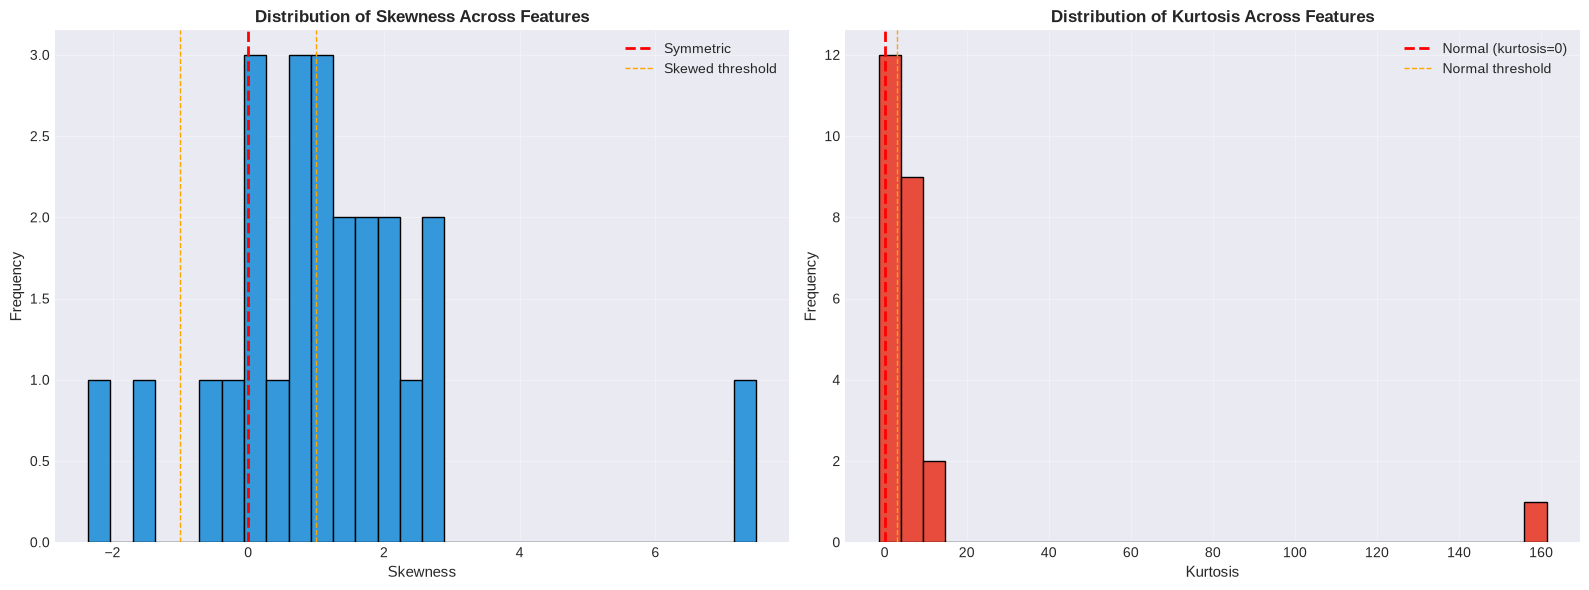


✓ Visualization saved: plots/13_distribution_shape.png


In [39]:
# Distribution shape analysis
if len(continuous_cols) > 0:
    print("=" * 80)
    print("DISTRIBUTION SHAPE ANALYSIS")
    print("=" * 80)

    from scipy.stats import skew, kurtosis

    shape_stats = []
    for col in continuous_cols:
        data = df[col].dropna()
        if len(data) > 3:
            skewness = skew(data)
            kurt = kurtosis(data)
            shape_stats.append(
                {
                    "Feature": col,
                    "Skewness": skewness,
                    "Kurtosis": kurt,
                    "Abs_Skewness": abs(skewness),
                    "Interpretation_Skew": "Highly Skewed"
                    if abs(skewness) > 1
                    else "Moderately Skewed"
                    if abs(skewness) > 0.5
                    else "Symmetric",
                    "Interpretation_Kurt": "Heavy Tailed"
                    if kurt > 3
                    else "Light Tailed"
                    if kurt < 0
                    else "Normal",
                }
            )

    if shape_stats:
        shape_df = pd.DataFrame(shape_stats).sort_values(
            "Abs_Skewness", ascending=False
        )
        print("\nDistribution Shape Statistics (Top 20 by absolute skewness):")
        display(shape_df.head(20))

        # Summary
        highly_skewed = shape_df[shape_df["Abs_Skewness"] > 1]
        if len(highly_skewed) > 0:
            print(
                f"\n⚠ {len(highly_skewed)} features are highly skewed (|skewness| > 1)"
            )
            print("   Consider log transformation or other normalization techniques.")

        # Visualize skewness distribution
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        axes[0].hist(shape_df["Skewness"], bins=30, color="#3498db", edgecolor="black")
        axes[0].axvline(
            x=0, color="red", linestyle="--", linewidth=2, label="Symmetric"
        )
        axes[0].axvline(
            x=1, color="orange", linestyle="--", linewidth=1, label="Skewed threshold"
        )
        axes[0].axvline(x=-1, color="orange", linestyle="--", linewidth=1)
        axes[0].set_title(
            "Distribution of Skewness Across Features", fontsize=12, fontweight="bold"
        )
        axes[0].set_xlabel("Skewness", fontsize=11)
        axes[0].set_ylabel("Frequency", fontsize=11)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].hist(shape_df["Kurtosis"], bins=30, color="#e74c3c", edgecolor="black")
        axes[1].axvline(
            x=0, color="red", linestyle="--", linewidth=2, label="Normal (kurtosis=0)"
        )
        axes[1].axvline(
            x=3, color="orange", linestyle="--", linewidth=1, label="Normal threshold"
        )
        axes[1].set_title(
            "Distribution of Kurtosis Across Features", fontsize=12, fontweight="bold"
        )
        axes[1].set_xlabel("Kurtosis", fontsize=11)
        axes[1].set_ylabel("Frequency", fontsize=11)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(
            str(PLOT_DIR / "13_distribution_shape.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()
        print("\n✓ Visualization saved: plots/13_distribution_shape.png")

## 17. Final Summary and Recommendations

Based on all analyses performed, here are the final recommendations for data preprocessing and modeling.


In [40]:
print("=" * 80)
print("FINAL SUMMARY AND RECOMMENDATIONS")
print("=" * 80)

recommendations = []

# Data quality recommendations
if "missing_df" in locals() and len(missing_df) > 0:
    high_missing = missing_df[missing_df["Missing Percentage"] > 20]
    if len(high_missing) > 0:
        recommendations.append(
            f"⚠ Consider removing or imputing {len(high_missing)} features with >20% missing values"
        )
    recommendations.append(
        "✓ Use appropriate imputation strategies (mean/median for continuous, mode for categorical)"
    )

# Feature engineering recommendations
if "correlations" in locals() and len(correlations) > 0:
    weak_corr = correlations[abs(correlations) < 0.1]
    if len(weak_corr) > 0:
        recommendations.append(
            f"⚠ {len(weak_corr)} features show very weak correlation (<0.1) - consider feature engineering or removal"
        )

# Transformation recommendations
if "shape_df" in locals():
    highly_skewed = (
        shape_df[shape_df["Abs_Skewness"] > 1] if "shape_df" in locals() else []
    )
    if len(highly_skewed) > 0:
        recommendations.append(
            f"⚠ {len(highly_skewed)} features are highly skewed - consider log/square root transformation"
        )

# Modeling recommendations
if "imbalance_ratio" in locals() and imbalance_ratio < 0.3:
    recommendations.append(
        "⚠ Use stratified sampling and consider SMOTE, class weights, or ensemble methods"
    )
    recommendations.append(
        "✓ Use appropriate metrics: AUC-ROC, Precision-Recall, F1-score (not just accuracy)"
    )

if "high_corr_pairs" in locals() and len(high_corr_pairs) > 0:
    recommendations.append(
        f"⚠ {len(high_corr_pairs)} highly correlated feature pairs detected - consider feature selection or PCA"
    )

recommendations.append(
    "✓ Use cross-validation with stratification to maintain class distribution"
)
recommendations.append(
    "✓ Consider feature selection techniques (mutual information, recursive feature elimination)"
)

print("\nRecommendations for Data Preprocessing and Modeling:")
for i, rec in enumerate(recommendations, 1):
    print(f"  {i}. {rec}")

print("\n" + "=" * 80)
print("EDA COMPLETE - All analyses finished!")
print("=" * 80)
print("\nTotal visualizations generated: 13")
print("Total summary files: 4")
print(f"\nAll outputs saved to {PLOT_DIR}")

FINAL SUMMARY AND RECOMMENDATIONS

Recommendations for Data Preprocessing and Modeling:
  1. ⚠ 78 features show very weak correlation (<0.1) - consider feature engineering or removal
  2. ⚠ 14 features are highly skewed - consider log/square root transformation
  3. ⚠ Use stratified sampling and consider SMOTE, class weights, or ensemble methods
  4. ✓ Use appropriate metrics: AUC-ROC, Precision-Recall, F1-score (not just accuracy)
  5. ⚠ 4 highly correlated feature pairs detected - consider feature selection or PCA
  6. ✓ Use cross-validation with stratification to maintain class distribution
  7. ✓ Consider feature selection techniques (mutual information, recursive feature elimination)

EDA COMPLETE - All analyses finished!

Total visualizations generated: 13
Total summary files: 4

All outputs saved to '../data/result/eda/plots/' directory
